Sourced from https://m2lines.github.io/L96_demo/notebooks/intro_ML_and_NNs.html

In [1]:
!nvidia-smi

Fri Jun 26 13:23:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:25:00.0 Off |                    0 |
| N/A   34C    P0             33W /  250W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
from m_star_predictor import (
    LinearRegression, FCNN, FCNN_corrected, fit_autoregressive
)
from utility import (
    MStarPredictorConfig, normalize, real_units,
    reduce_dataset, compute_rmse, prepare_data
)

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

# Ensuring reproducibility
random_state = 123
np.random.seed(random_state)
torch.manual_seed(random_state);
sklear_random_state = random_state

In [2]:
from utility import MStarAutoregressivePredictorConfig

In [3]:
if torch.cuda.is_available():
    print("GPU is available.")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. PyTorch is likely using the CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

GPU is available.
Number of GPUs: 1
Current GPU name: NVIDIA A100-SXM4-40GB
Using device: cuda


In [4]:
data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_expanded_2283_corrected'
validation_dataset_name = 'ePBL_paper_validation_2283_corrected'
dataset_filename = f"{dataset_name}_features_and_targets_with_dM"
validation_dataset_filename = f"{validation_dataset_name}_features_and_targets_with_dM"
data = pd.read_csv(os.path.join(data_directory, f"{dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{validation_dataset_filename}.csv"))

In [5]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [6]:
drop_first_inertial_T = False

if drop_first_inertial_T:
    n_timesteps = np.load(f"ePBL_paper_expanded_2283_corrected_dataset_M_target_dropped_first_inertial_T_timesteps.npy")
    n_timesteps_val = np.load(f"ePBL_paper_validation_2283_corrected_dataset_M_target_dropped_first_inertial_T_timesteps.npy")
else:
    n_timesteps, n_timesteps_val = 432, 432  # TODO: make it not hard-coded

In [28]:
### CONFIG ###

predictor_name = "predictor_1"
predictor_dir = os.path.join("m_star_autoregressive_predictors", predictor_name)
os.makedirs(predictor_dir, exist_ok=True)
weights_save_path = os.path.join(predictor_dir, "weights.pt")

feature_names = ["M", "f", "u_star", "B", "bl_tke", "surf_mag", "surf_angle", "SS_bl", "NN_bl"]
# feature_names = ["f_H_over_u_star", "NN_over_SS", "B_over_u_star_squared_f", "Ms_im1_over_ePBL_Ms_im1"]
# feature_names = data.keys()[6:]
# drop = [f"{num:.2f}" for num in np.arange(0.0,0.11,0.01)]
# drop = ["tke_", "eps", "wb"] 
# feature_names = [name for name in feature_names if not any(d in name for d in drop)]
feature_transforms = {"": ""}
target_name = "M_i+1"
# target_transform = "log10"
target_transform = ""

n_neurons = None
n_hidden_layers = None
n_neurons_list = [64, 32, 32]
learning_rate = 5e-5
weight_decay = 5e-4
activation = "tanh"
n_epochs = 3000
network = "fcnn_corrected"
k=4
predict_tendency=True
n_ar=1

loss = "mse_loss"

input_size = len(feature_names)

if activation == "tanh":
    activation_fn = torch.nn.Tanh()
elif activation == "relu":
    activation_fn = torch.nn.ReLU()

if loss == "mse_loss":
    loss_fn = torch.nn.MSELoss()

In [8]:
feature_names

['M', 'f', 'u_star', 'B', 'bl_tke', 'surf_mag', 'surf_angle', 'SS_bl', 'NN_bl']

In [9]:
X, y = prepare_data(
    dataframe=data,
    feature_names=feature_names,
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform,
    autoregressive=True,
    n_timesteps=n_timesteps
)

X_val, y_val = prepare_data(
    dataframe=validation_data,
    feature_names=feature_names,
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform,
    autoregressive=True,
    n_timesteps=n_timesteps_val
)

In [10]:
print(X.shape, y.shape)
print(X_val.shape, y_val.shape)

torch.Size([3240, 432, 9]) torch.Size([3240, 432, 1])
torch.Size([216, 432, 9]) torch.Size([216, 432, 1])


In [11]:
train_batch_size = int(1396440 / 16)
test_batch_size = int(93096 / 2)
print(train_batch_size, test_batch_size)

87277 46548


In [12]:
X_mean = X.reshape(-1,len(feature_names)).mean(dim=0)
X_std = X.reshape(-1,len(feature_names)).std(dim=0)
y_mean = y.reshape(-1,1).mean(dim=0)
y_std = y.reshape(-1,1).std(dim=0)

X_train = normalize(data=X, mean=X_mean, std=X_std)
X_test = normalize(data=X_val, mean=X_mean, std=X_std)
y_train = normalize(data=y, mean=y_mean, std=y_std)
y_test = normalize(data=y_val, mean=y_mean, std=y_std)

input_size = len(X_std[X_std!=0])

train_dataset = Data.TensorDataset(X_train, y_train)
test_dataset = Data.TensorDataset(X_test, y_test)

train_loader = Data.DataLoader(dataset=train_dataset, batch_size=train_batch_size, shuffle=True, num_workers=8, pin_memory=True)
test_loader = Data.DataLoader(dataset=test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=8, pin_memory=True)

In [13]:
linear_network = LinearRegression(input_size=input_size)
if network == "fcnn":
    fcnn_network = FCNN(input_size=input_size, n_hidden_layers=n_hidden_layers, n_neurons=n_neurons, activation=activation_fn)
elif network == "fcnn_corrected":
    fcnn_network = FCNN_corrected(input_size=input_size, n_neurons_list=n_neurons_list, activation=activation_fn)

In [14]:
optimizer_linear = optim.Adam(
    linear_network.parameters(), lr=5e-3, weight_decay=weight_decay
)
optimizer_fcnn = optim.Adam(
    fcnn_network.parameters(), lr=learning_rate, weight_decay=weight_decay
)

In [15]:
n_epochs_linear = 500
n_epochs_fcnn = n_epochs

In [16]:
for epoch, train_losses_linear, test_losses_linear in fit_model(linear_network, loss_fn, optimizer_linear, train_loader, test_loader, n_epochs_linear, device):
    pass

NameError: name 'fit_model' is not defined

In [17]:
for epoch, train_losses, test_losses in fit_autoregressive(fcnn_network, loss_fn, optimizer_fcnn, train_loader, test_loader, n_epochs_fcnn, device, k=k, predict_tendency=predict_tendency):
    pass

Epoch 1 completed. Train loss: 0.19503428041934967; test loss: 324.22064208984375.
Epoch 2 completed. Train loss: 0.19157597422599792; test loss: 314.90496826171875.
Epoch 3 completed. Train loss: 0.1881592571735382; test loss: 305.763916015625.
Epoch 4 completed. Train loss: 0.18478453159332275; test loss: 296.8114013671875.
Epoch 5 completed. Train loss: 0.1814521849155426; test loss: 288.0679016113281.
Epoch 6 completed. Train loss: 0.17816263437271118; test loss: 279.5469055175781.
Epoch 7 completed. Train loss: 0.17491623759269714; test loss: 271.2560119628906.
Epoch 8 completed. Train loss: 0.17171335220336914; test loss: 263.1990661621094.
Epoch 9 completed. Train loss: 0.16855430603027344; test loss: 255.37770080566406.
Epoch 10 completed. Train loss: 0.16543936729431152; test loss: 247.7917938232422.
Epoch 11 completed. Train loss: 0.1623687595129013; test loss: 240.4399871826172.
Epoch 12 completed. Train loss: 0.1593427062034607; test loss: 233.32012939453125.
Epoch 13 compl

In [ ]:
train_losses

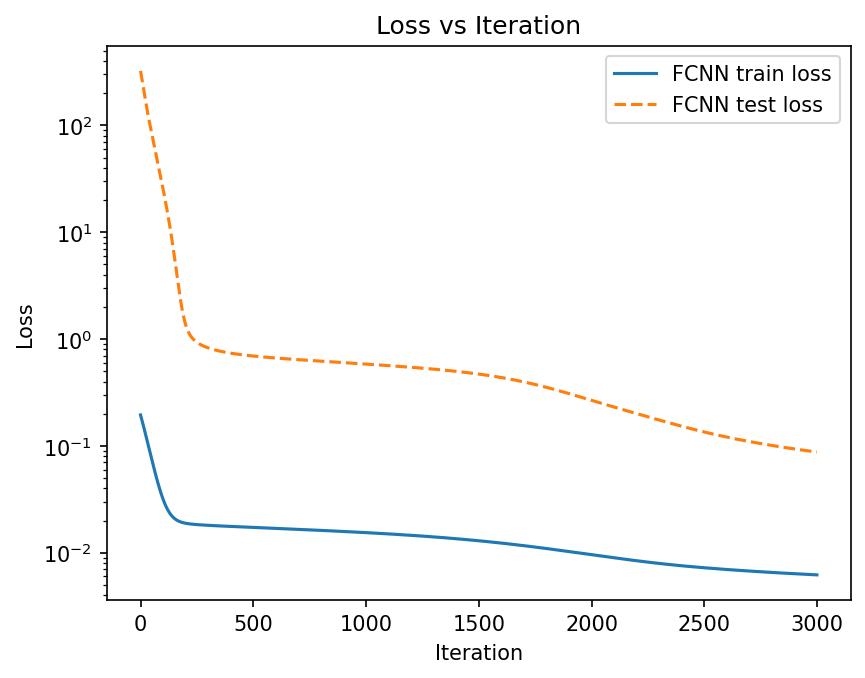

In [18]:
plt.figure(dpi=150)

# plt.plot(train_losses_linear, label="Linear train loss")
# plt.plot(test_losses_linear, linestyle="--", label="Linear test loss")

plt.plot(train_losses, label="FCNN train loss")
plt.plot(test_losses, linestyle="--", label="FCNN test loss")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Loss vs Iteration")
plt.show();

In [19]:
def _step(network, x, n_ar, predict_tendency):
    """One forward pass. Returns the next state M (batch, n_ar)."""
    out = network(x)
    return x[:, :n_ar] + out if predict_tendency else out

def predict_autoregressive(network, batch_x, n_ar=1, predict_tendency=False):
    """Free rollout. batch_x: (batch, seq_len, n_ar + n_forcings)."""
    seq_len = batch_x.shape[1]
    x = batch_x[:, 0, :]
    preds = []

    for t in range(seq_len):
        y = _step(network, x, n_ar, predict_tendency)
        preds.append(y)
        if t + 1 < seq_len:
            x = torch.cat([y, batch_x[:, t + 1, n_ar:]], dim=-1)

    return torch.stack(preds, dim=1)      # (batch, seq_len, n_ar) -- states, not tendencies

In [20]:
torch.save(fcnn_network.state_dict(), weights_save_path)

In [29]:
if target_transform == "log10":
    fcnn_prediction_full = 10**real_units(predict_autoregressive(fcnn_network, X_train.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)
    fcnn_val_prediction_full = 10**real_units(predict_autoregressive(fcnn_network, X_test.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)
elif target_transform == "sqrt":
    fcnn_prediction_full = real_units(predict_autoregressive(fcnn_network, X_train.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)**2
    fcnn_val_prediction_full = real_units(predict_autoregressive(fcnn_network, X_test.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)**2
else:
    fcnn_prediction_full = real_units(predict_autoregressive(fcnn_network, X_train.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)
    fcnn_val_prediction_full = real_units(predict_autoregressive(fcnn_network, X_test.to(device), n_ar=n_ar, predict_tendency=predict_tendency).cpu(), mean=y_mean, std=y_std)

In [30]:
rmse = compute_rmse(y_pred=fcnn_val_prediction_full.reshape(-1,1), y_true=y_val.reshape(-1,1))

In [31]:
rmse

tensor(1.2091e-06, grad_fn=<SqrtBackward0>)

In [32]:
config = MStarAutoregressivePredictorConfig(
    dataset_name=dataset_name,
    dataset_filename=dataset_filename,
    validation_dataset_name=validation_dataset_name,
    validation_dataset_filename=validation_dataset_filename,
    weights_save_path=weights_save_path,
    feature_names=feature_names,
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform,
    n_neurons=n_neurons,
    n_hidden_layers=n_hidden_layers,
    n_neurons_list=n_neurons_list,
    network=network,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    activation=activation,
    loss=loss,
    n_epochs=epoch,
    random_state=random_state,
    train_batch_size=train_batch_size,
    test_batch_size=test_batch_size,
    feature_mean=X_mean.detach().numpy().tolist(),
    feature_std=X_std.detach().numpy().tolist(),
    target_mean=y_mean.detach().numpy().tolist(),
    target_std=y_std.detach().numpy().tolist(),
    train_loss_trajectory=train_losses,
    test_loss_trajectory=test_losses,
    n_time_steps=n_timesteps,
    n_time_steps_val=n_timesteps_val,
    rmse=rmse.item(),
    k=k,
    predict_tendency=predict_tendency
)

In [33]:
json_string = json.dumps(asdict(config))
json_save_path = os.path.join(predictor_dir, "config.json")

with open(json_save_path, "w") as f:
    json.dump(asdict(config), f)

Text(0.5, 0, '$M_{pred}$')

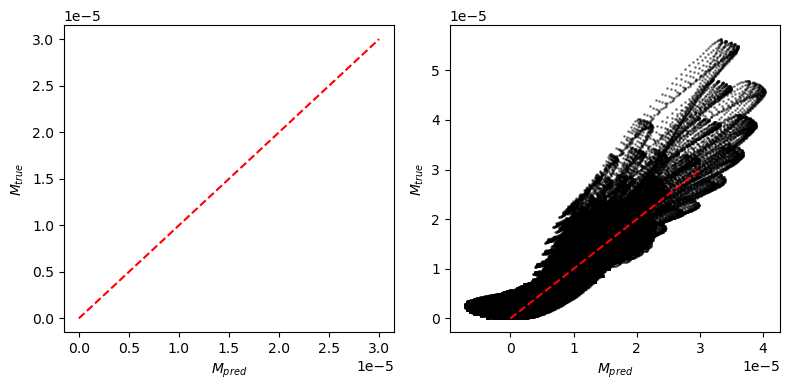

In [34]:
xs, ys = np.linspace(0., 3e-5, 1000), np.linspace(0., 3e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4), tight_layout=True)
# ax[0].scatter(linear_prediction_full.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
# ax[0].set_yscale("log")
# ax[0].set_xscale("log")

ax[1].scatter(fcnn_prediction_full.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
# ax[1].set_yscale("log")
# ax[1].set_xscale("log")
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
# ax[1].set_xlim(-3e-6,8e-6)
# ax[1].set_ylim(-3e-6,8e-6)

# plt.savefig("inst_M_true_pred_with_utau.png", dpi=300)

In [33]:
fcnn_val_diff = fcnn_val_prediction_full.detach().numpy()[1:] - fcnn_val_prediction_full.detach().numpy()[:-1]
y_val_diff = y_val[1:] - y_val[:-1]

NameError: name 'fcnn_val_diff' is not defined

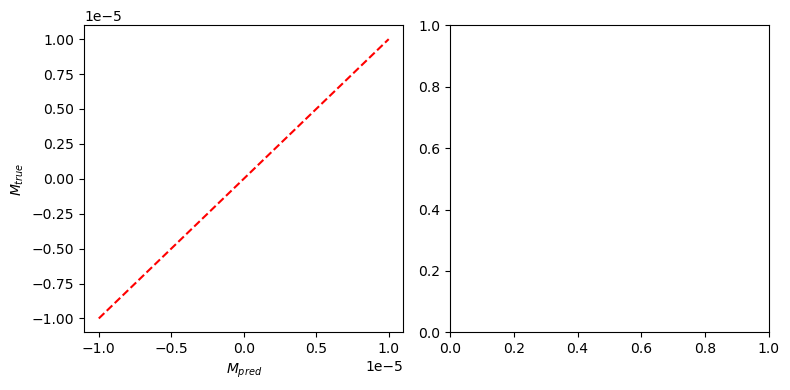

In [30]:
xs, ys = np.linspace(-1e-5, 1e-5, 1000), np.linspace(-1e-5, 1e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4), tight_layout=True)
# ax[0].scatter(linear_prediction_full.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
# ax[0].set_yscale("log")
# ax[0].set_xscale("log")

ax[1].scatter(fcnn_val_diff, y_val_diff, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
# ax[1].set_yscale("log")
# ax[1].set_xscale("log")
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
# ax[1].set_xlim(1e-10,1e-3)
# ax[1].set_ylim(1e-10,1e-3)

# plt.savefig("inst_M_true_pred_with_utau.png", dpi=300)

(-0.4, 0.4)

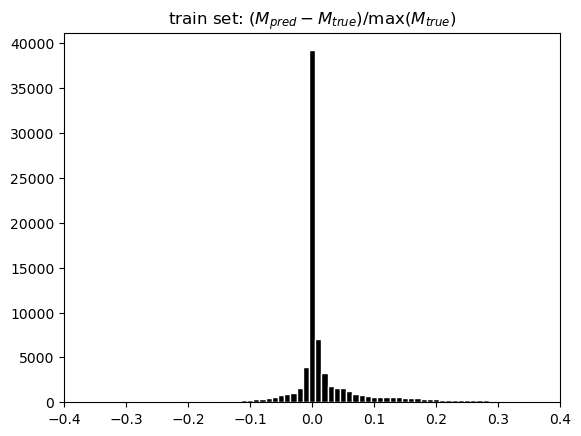

In [73]:
plt.hist((fcnn_prediction_full.detach().numpy()-y.detach().numpy())/y.mean().detach().numpy(), np.arange(-0.405,0.425,0.01), color="black", ec="white");
plt.title("train set: $(M_{pred}-M_{true})/\max(M_{true})$");
plt.xlim(-0.4,0.4)

(-0.4, 0.4)

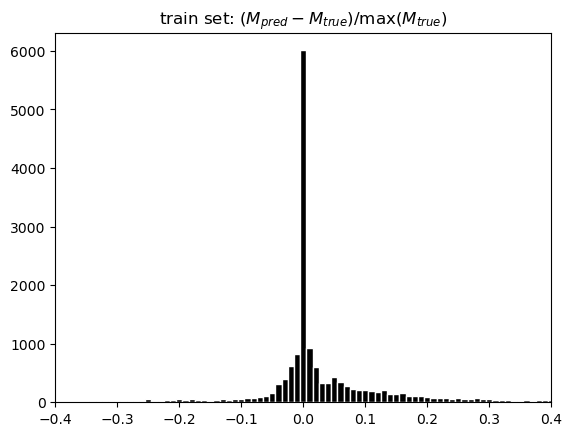

In [74]:
plt.hist((fcnn_val_prediction_full.detach().numpy()-y_val.detach().numpy())/y.mean().detach().numpy(), np.arange(-0.405,0.425,0.01), color="black", ec="white");
plt.title("train set: $(M_{pred}-M_{true})/\max(M_{true})$");
plt.xlim(-0.4,0.4)

Traceback (most recent call last):
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/queues.py", line 250, in _feed
    send_bytes(obj)
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/connection.py", line 411, in _send_bytes
    self._send(header + buf)
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/connection.py", line 368, in _send
    n = write(self._handle, buf)
OSError: [Errno 9] Bad file descriptor
Traceback (most recent call last):
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/queues.py", line 240, in _feed
    writer_close()
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/multiprocessing/connection.py", line 177, in close
    self._close()
  File "/home/mm6851/miniconda3/envs/L96M2lin

Text(0.5, 0, '$M_{pred}$')

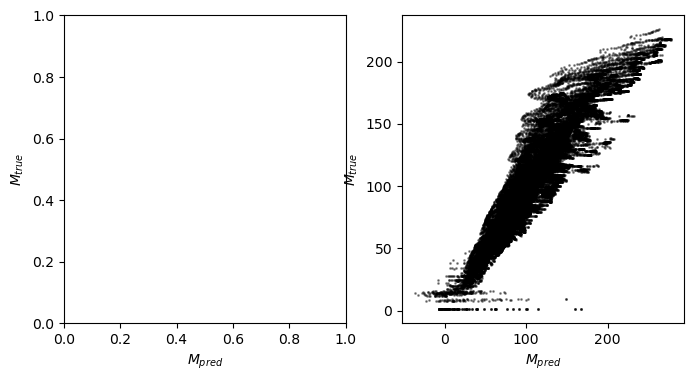

In [27]:
xs, ys = np.linspace(0., 3e-5, 1000), np.linspace(0., 3e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4))
# ax[0].scatter(linear_val_prediction_full.detach().numpy(), y_val, color="black", s=1, alpha=.4)
# ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
# ax[0].set_yscale("log")
# ax[0].set_xscale("log")

ax[1].scatter(fcnn_val_prediction_full.detach().numpy(), y_val, color="black", s=1, alpha=.4)
# ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
# ax[1].set_yscale("log")
# ax[1].set_xscale("log")

/tmp/ipykernel_1104122/3343130403.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


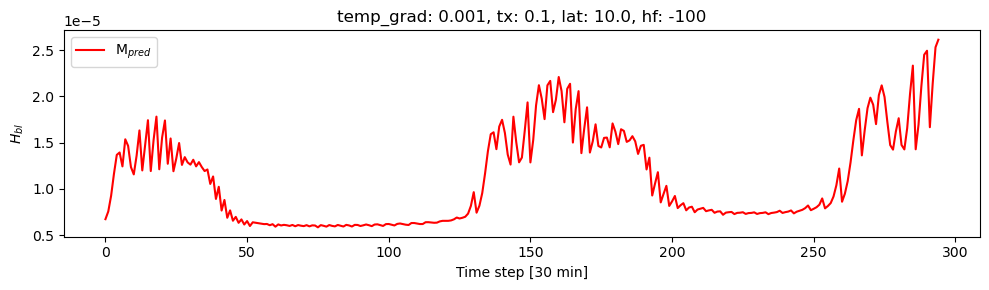

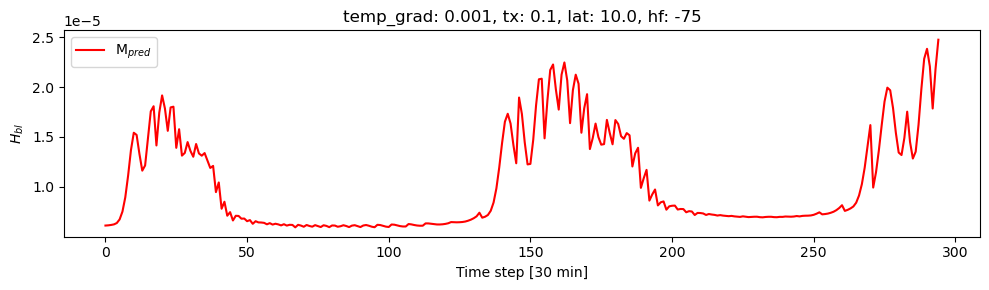

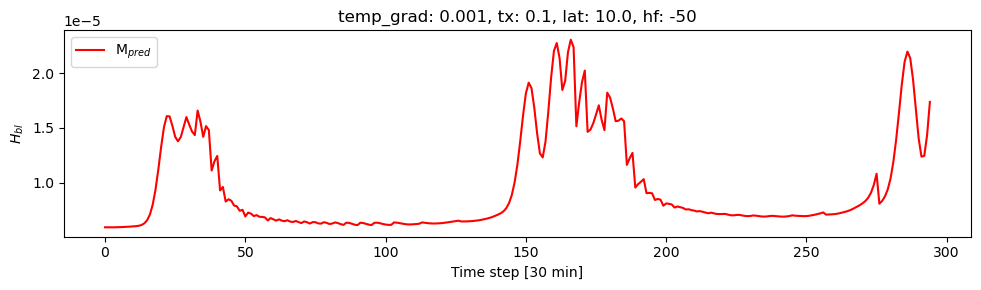

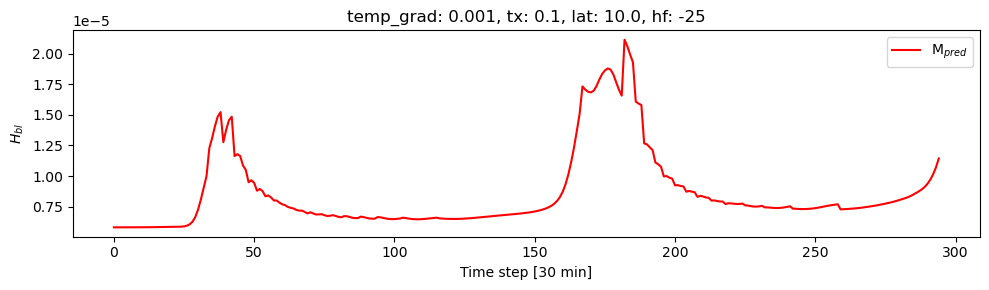

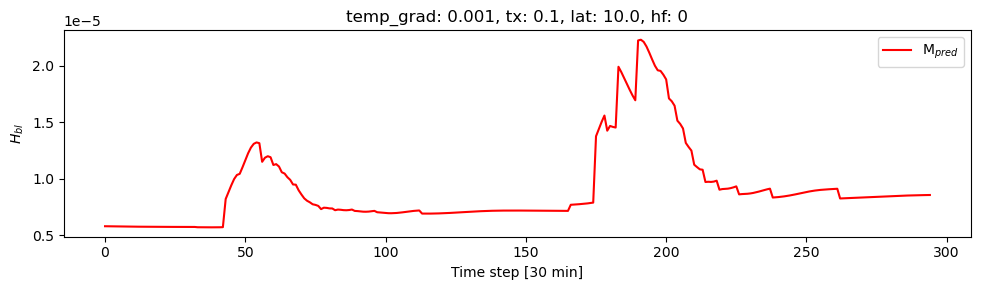

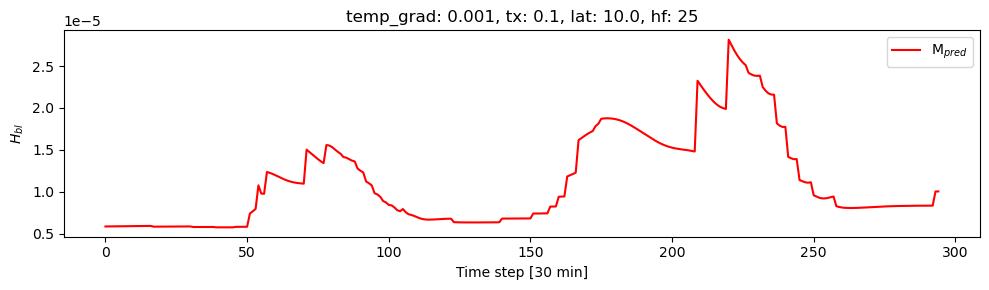

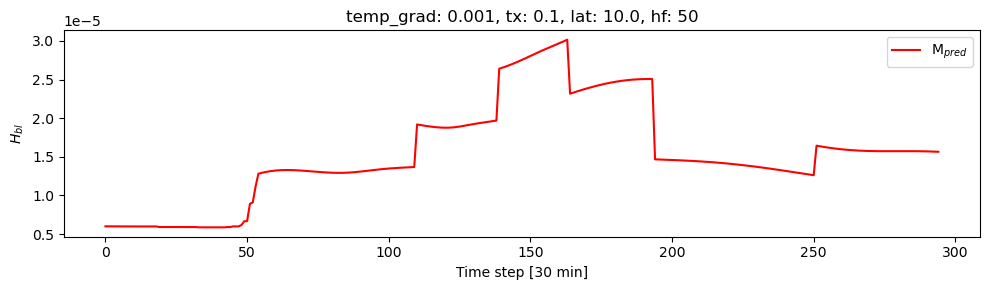

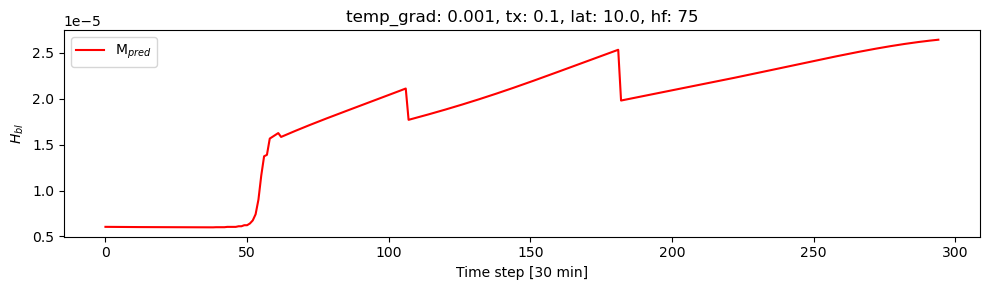

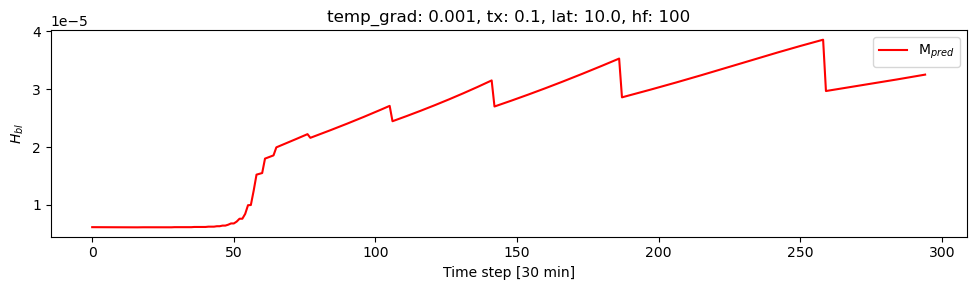

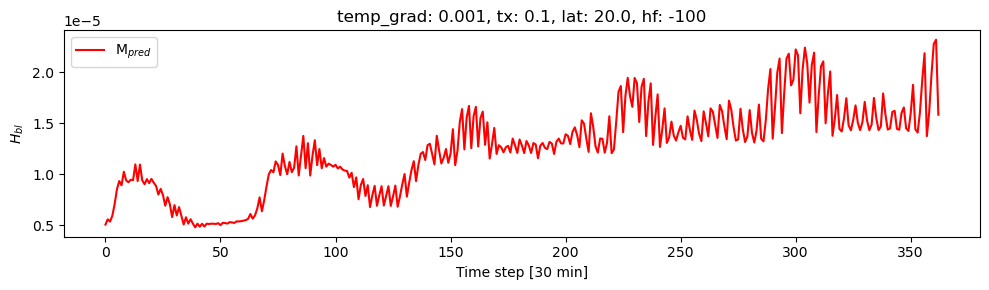

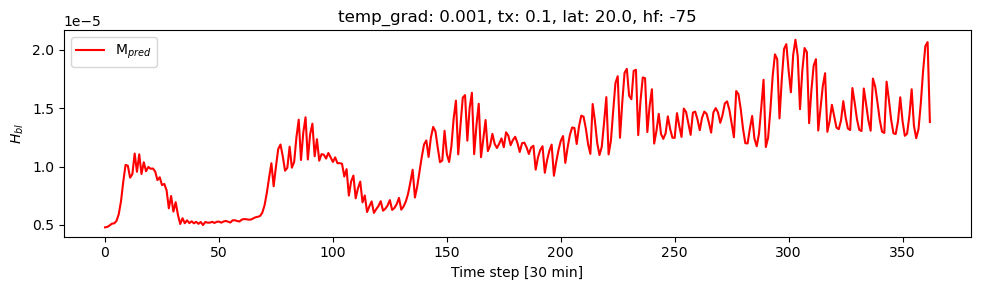

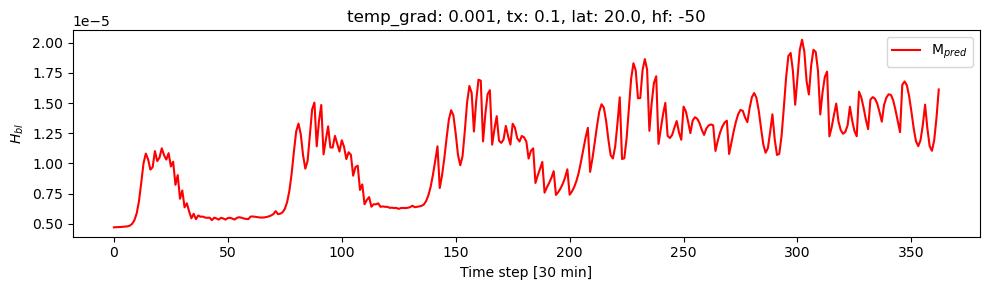

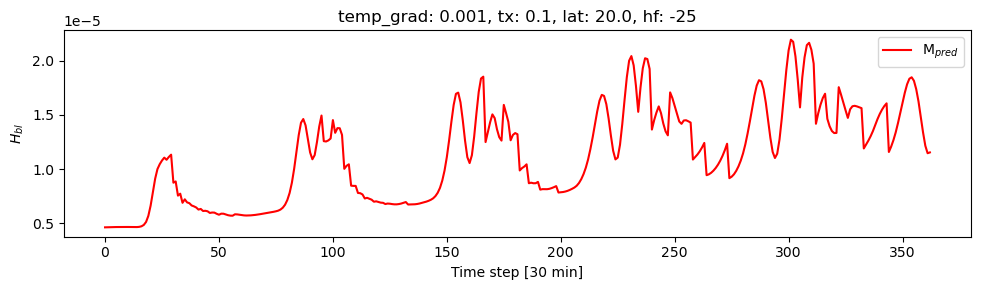

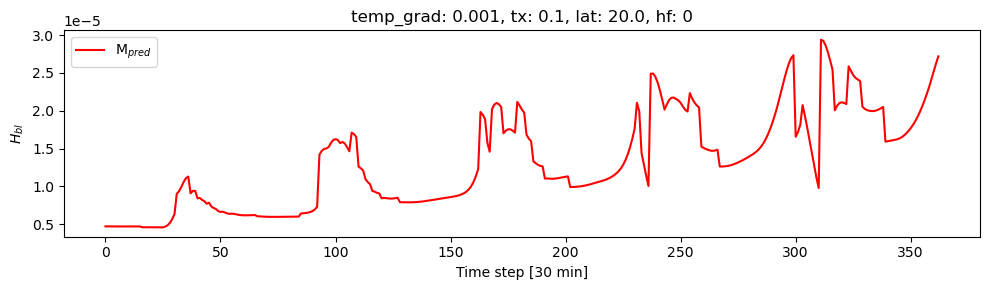

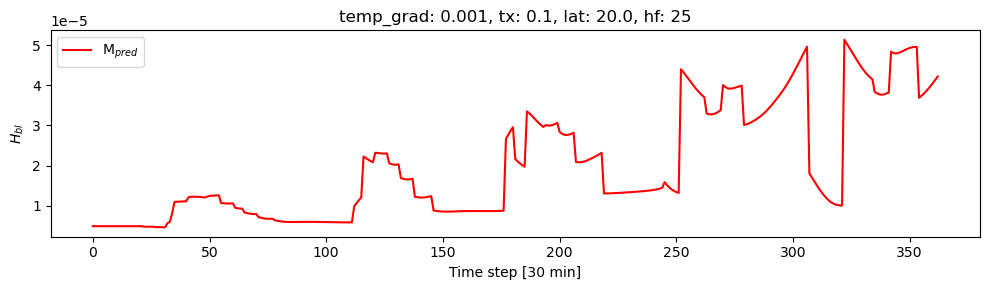

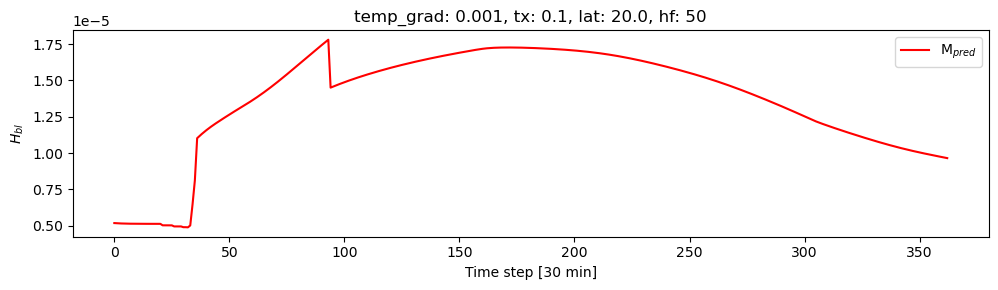

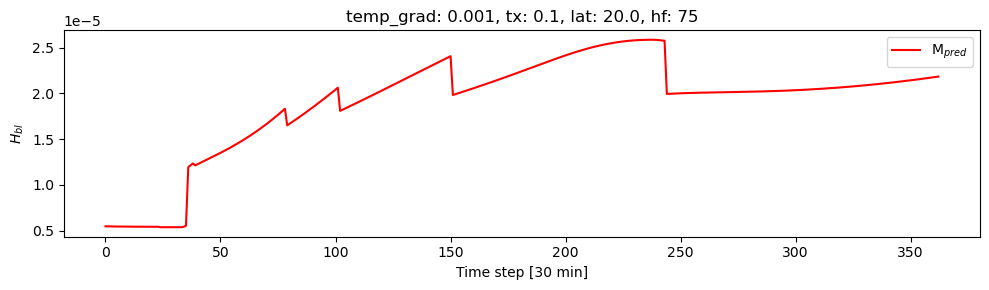

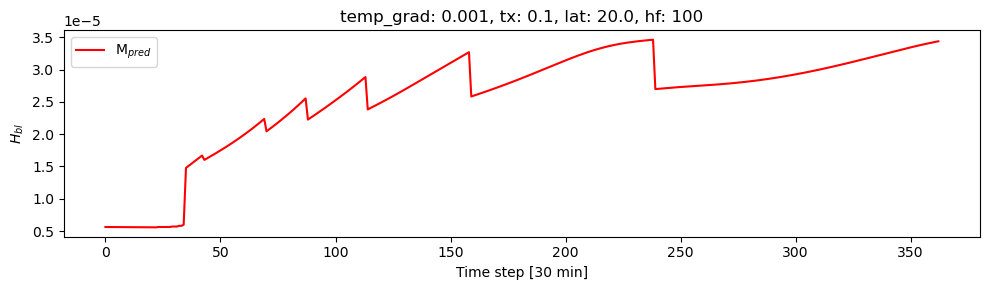

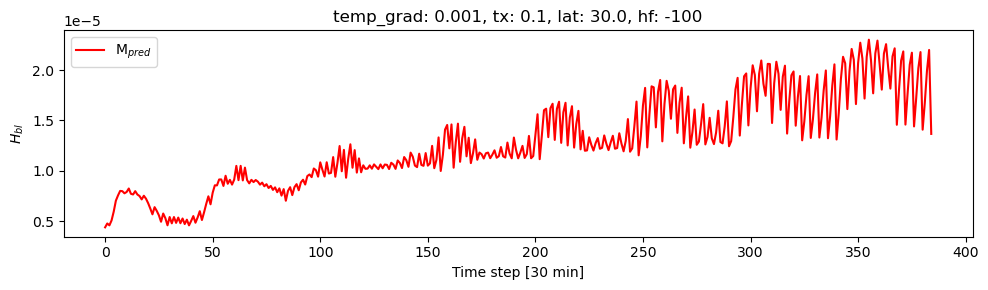

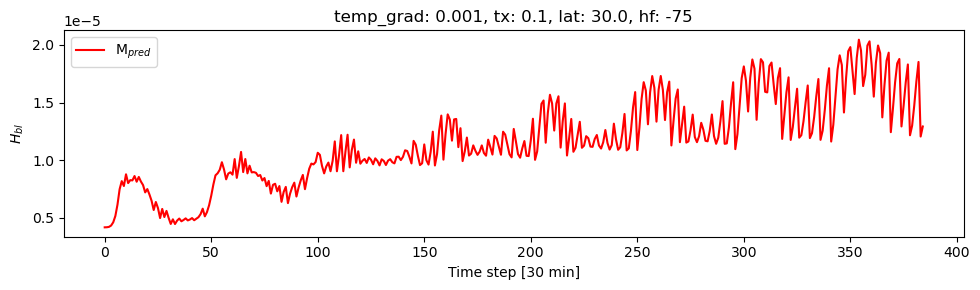

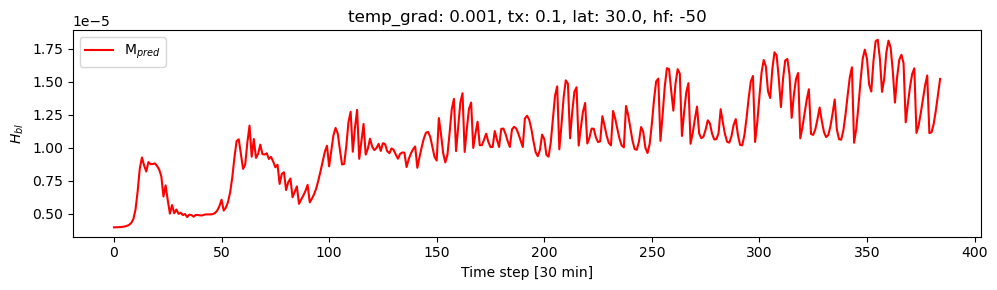

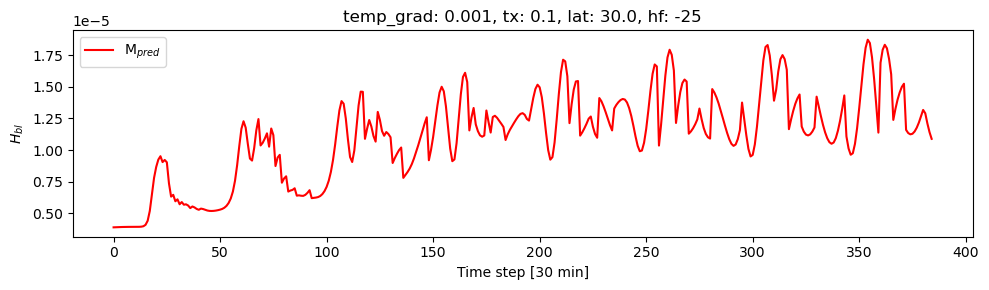

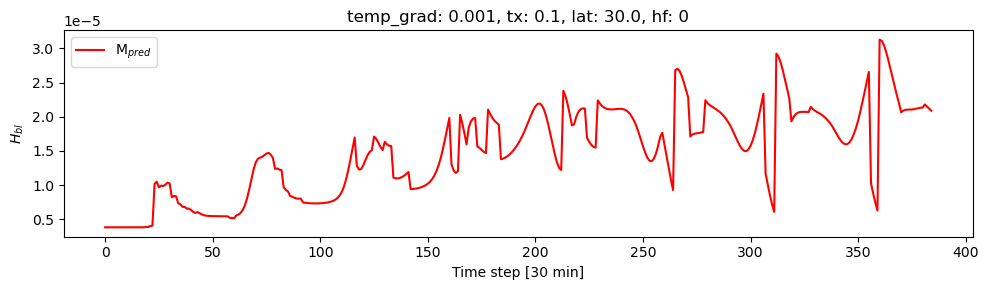

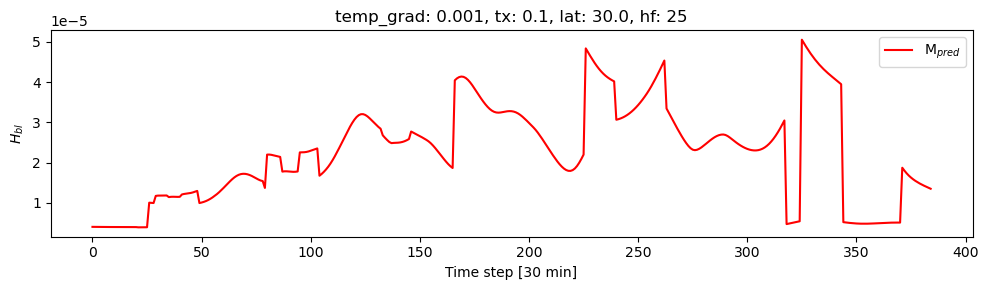

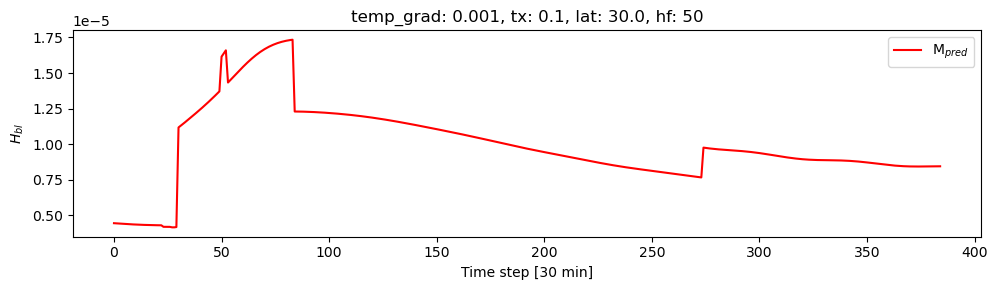

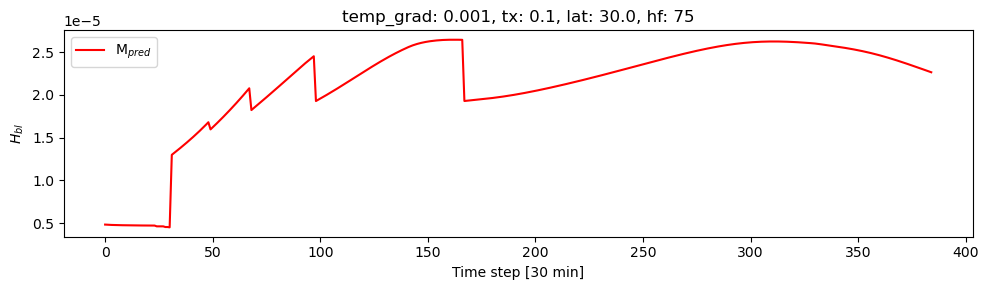

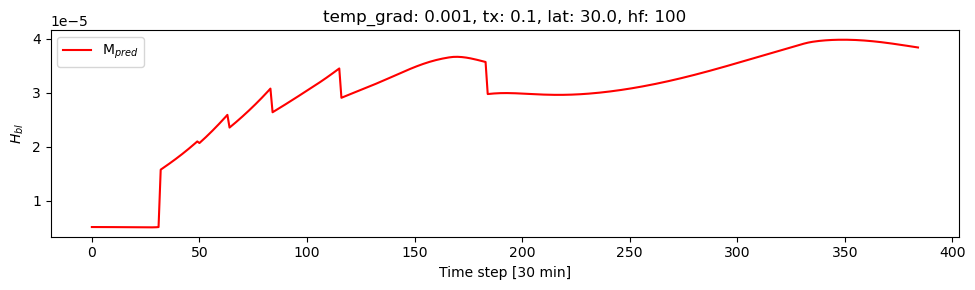

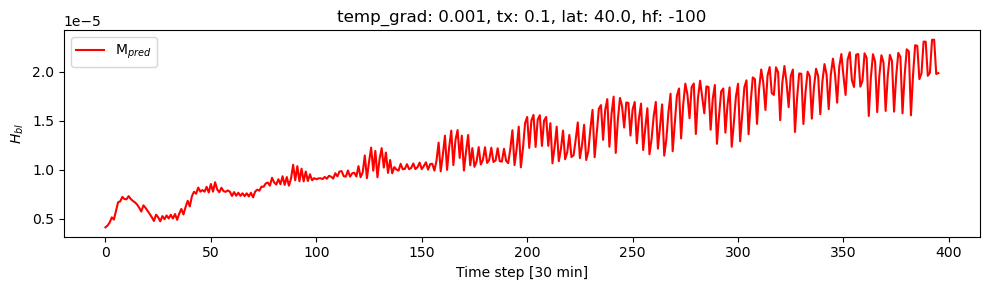

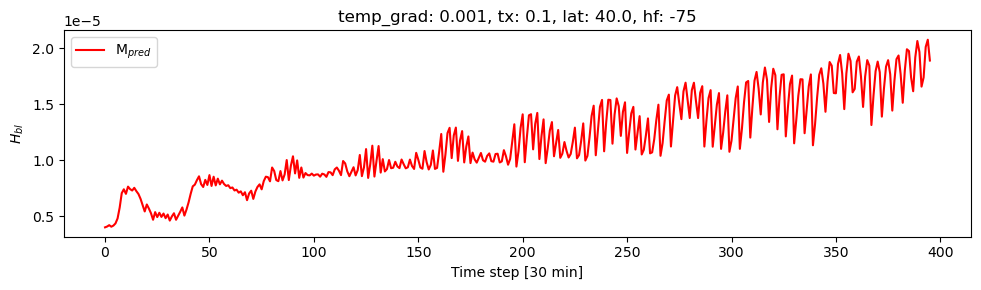

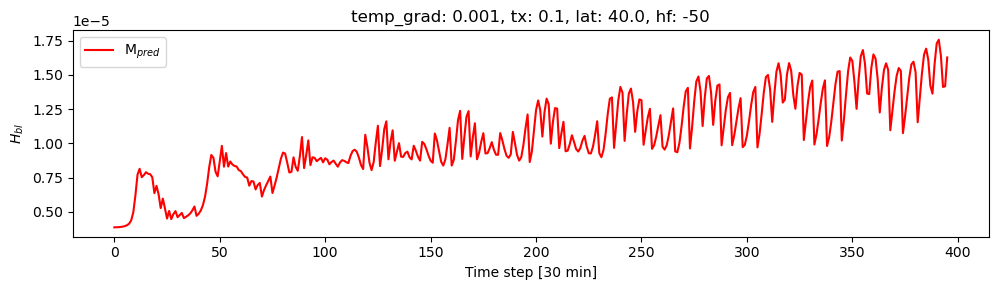

In [73]:
current_timestep = 0

for i in range(30):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(X.detach().numpy()[current_timestep:current_timestep+n_timesteps[i],7], label="M$_{pred}$", color="red")
    # plt.plot(y[n_timesteps*i:n_timesteps*(i+1)], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("$H_{bl}$")
    plt.legend()
    current_timestep += n_timesteps[i]

In [37]:
start, end = 400, 430
current_timestep = sum(n_timesteps[:start])

for i in range(start, end):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_full.detach().numpy()[current_timestep:current_timestep+n_timesteps[i]], label="M$_{pred}$", color="red")
    plt.plot(y[current_timestep:current_timestep+n_timesteps[i]], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()
    current_timestep += n_timesteps[i]

TypeError: 'int' object is not subscriptable

In [34]:
start, end = 90, 120
current_timestep = sum(n_timesteps_val[:start])

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_val_prediction_full.detach().numpy()[current_timestep:current_timestep+n_timesteps_val[i]], label="M$_{pred}$", color="red")
    plt.plot(y_val[current_timestep:current_timestep+n_timesteps_val[i]], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()
    current_timestep += n_timesteps_val[i]

TypeError: 'int' object is not subscriptable

/tmp/ipykernel_2147809/323354850.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


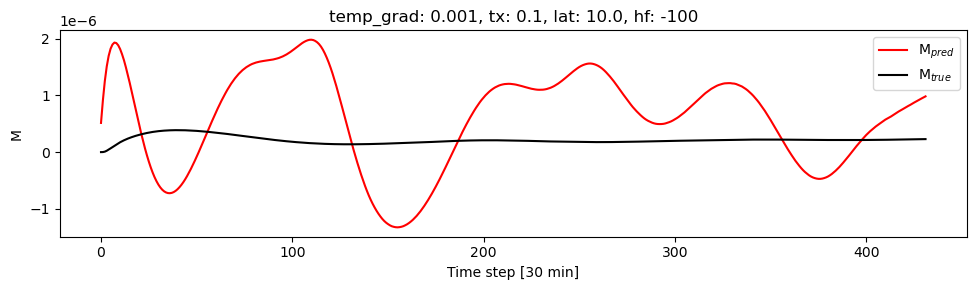

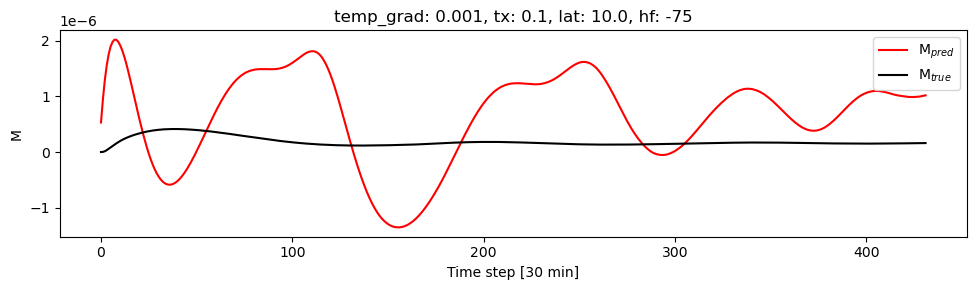

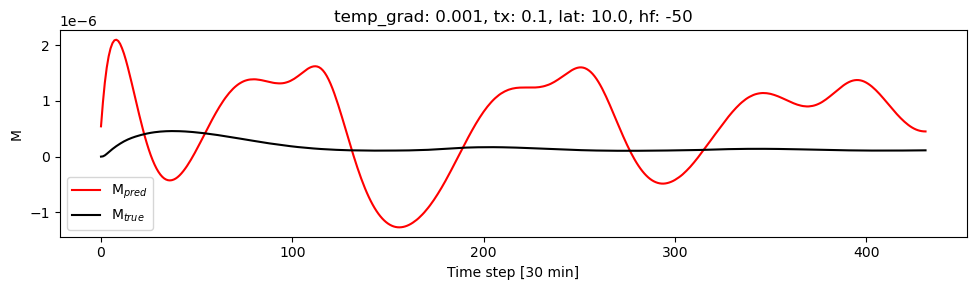

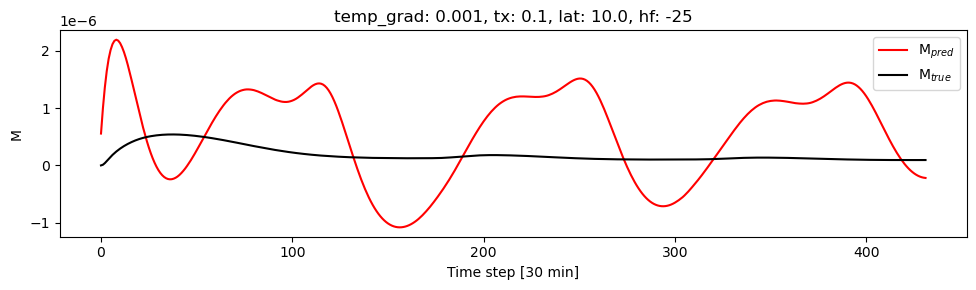

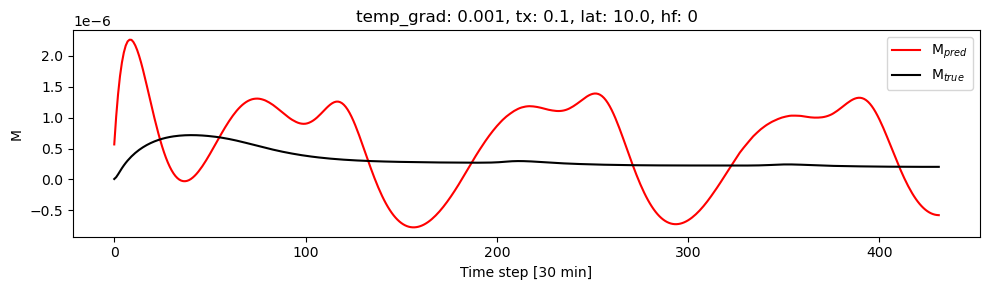

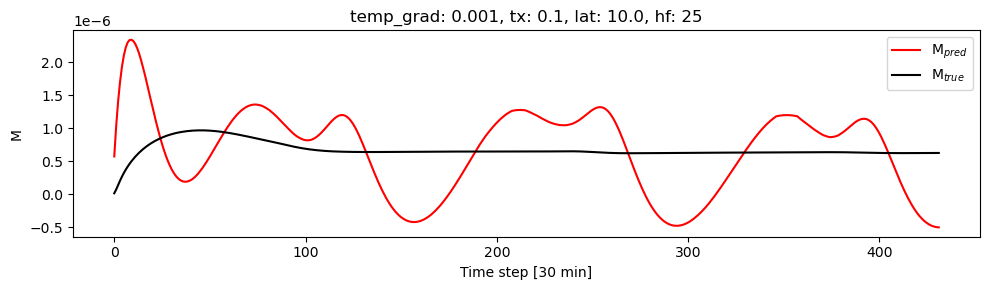

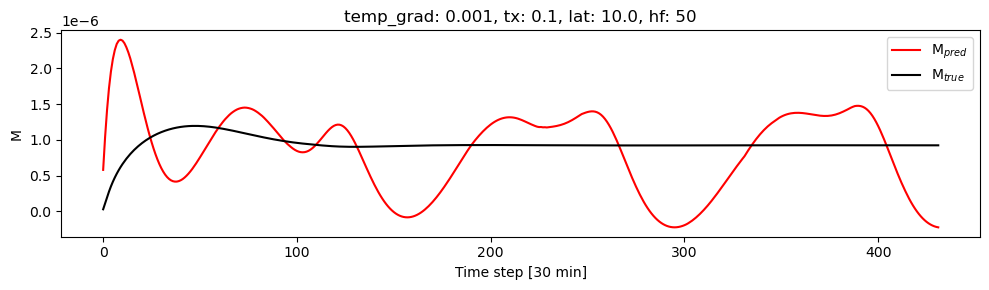

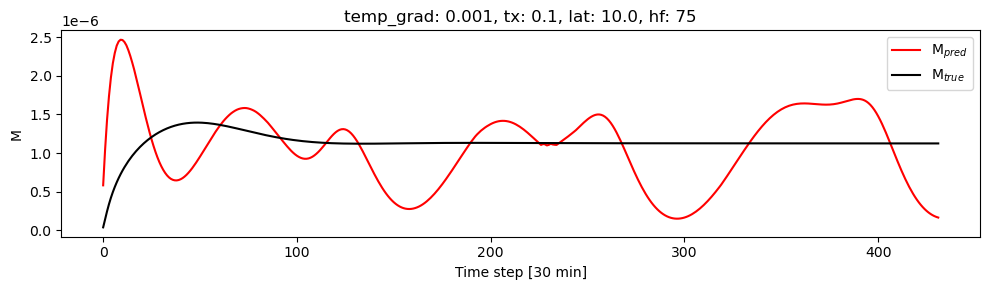

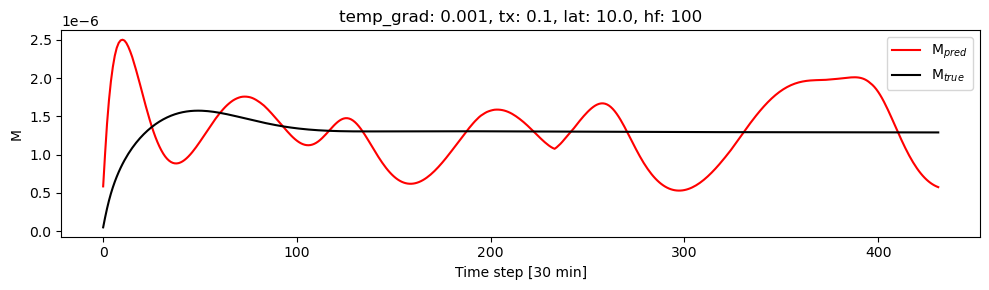

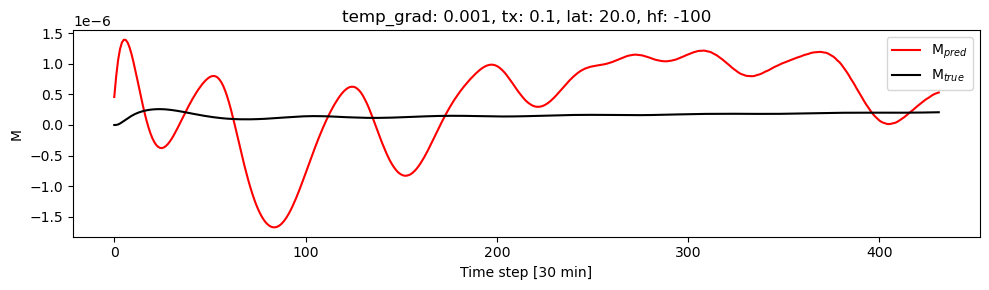

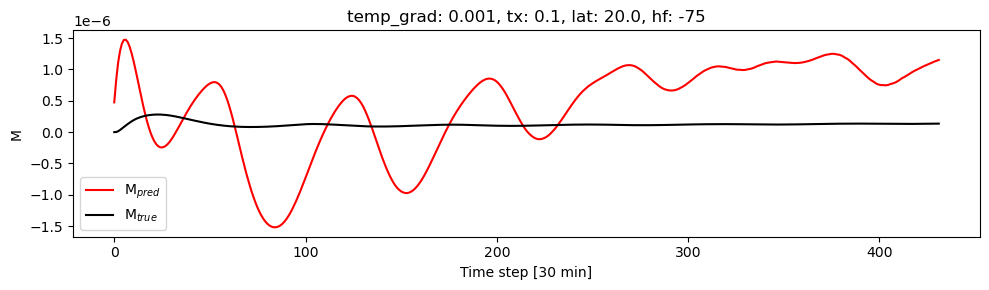

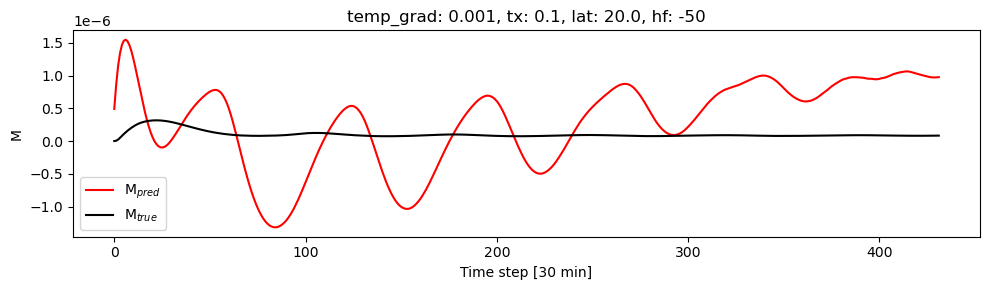

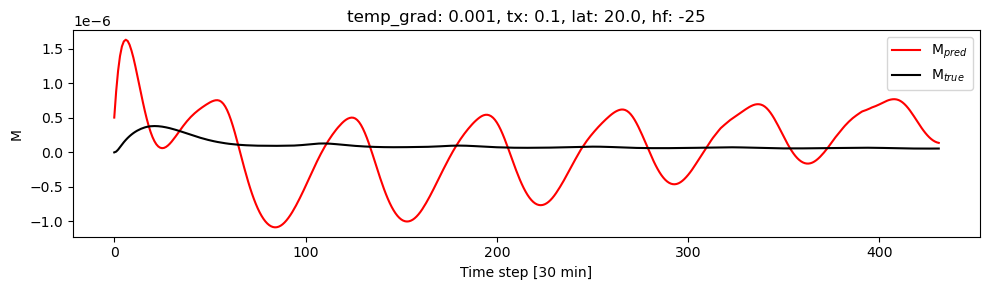

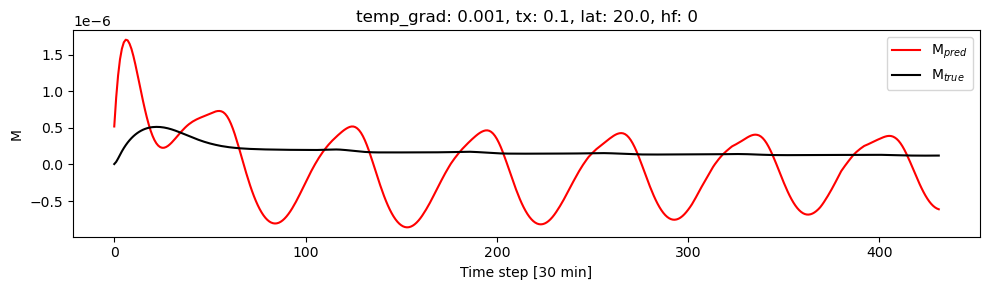

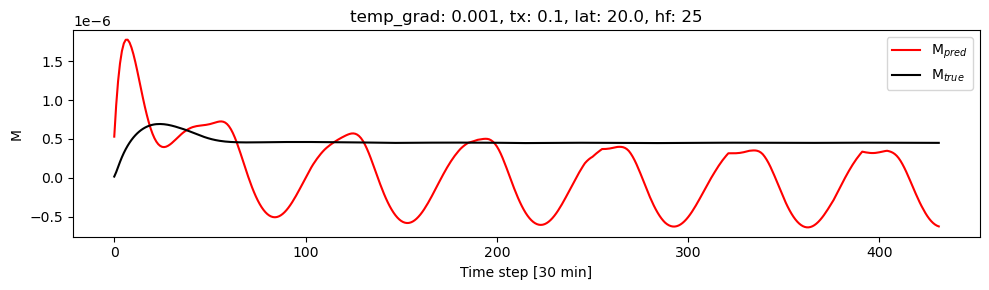

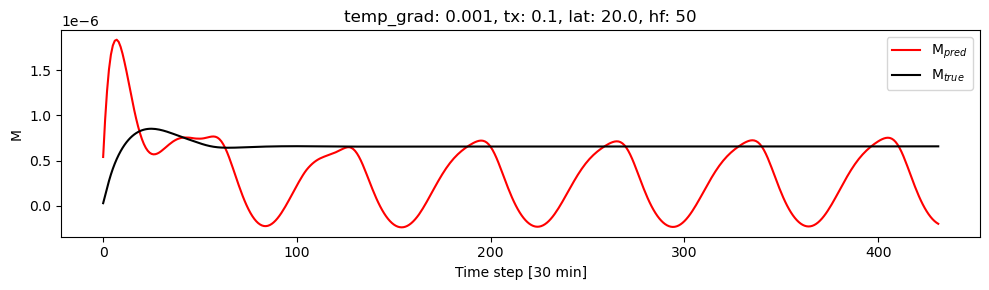

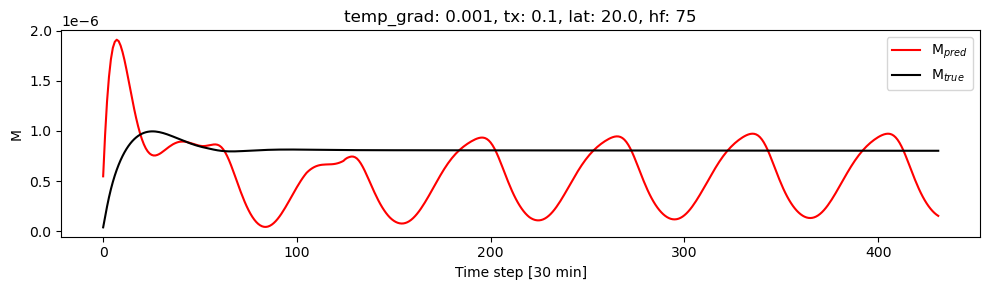

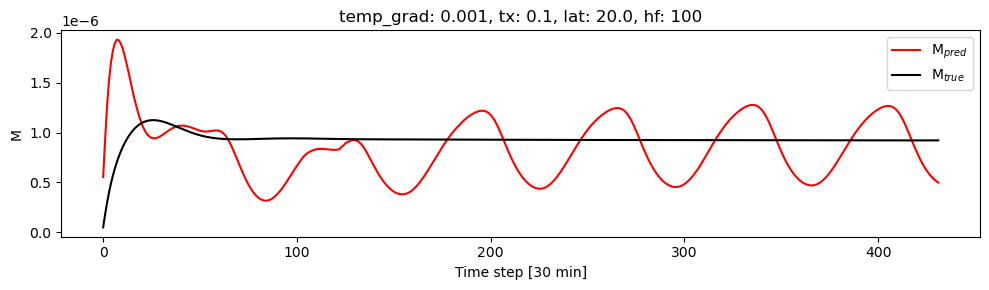

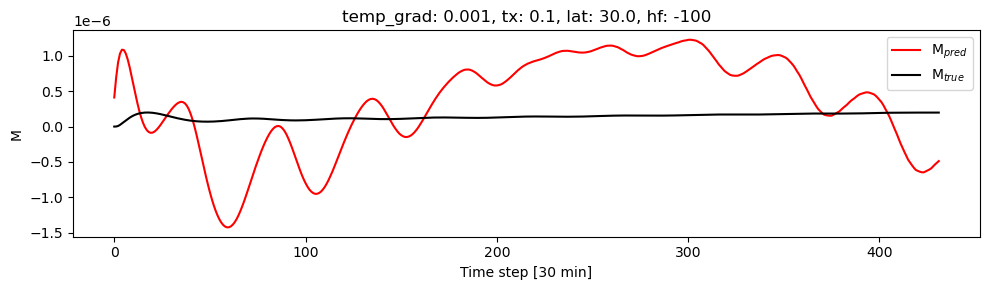

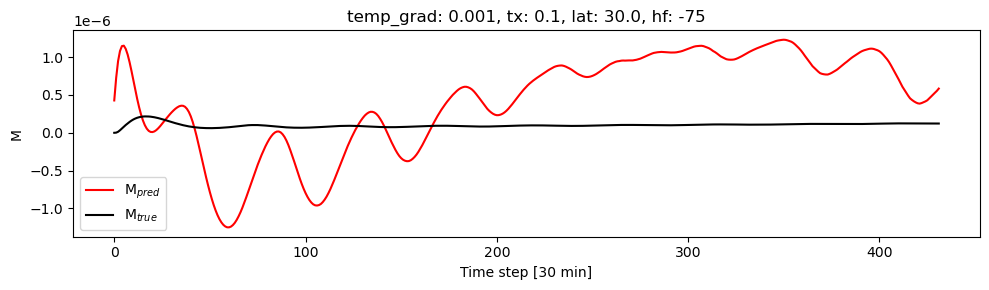

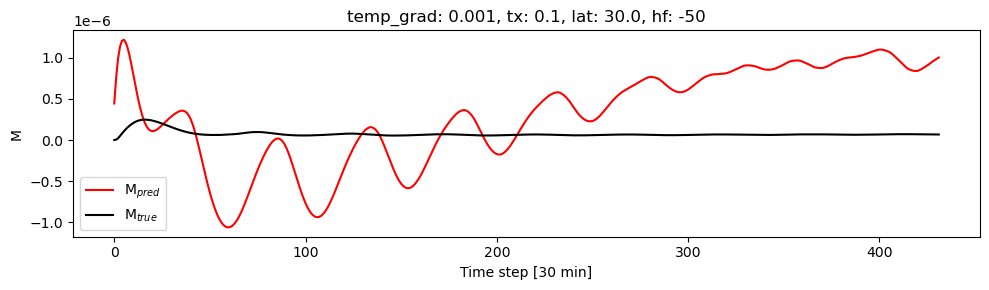

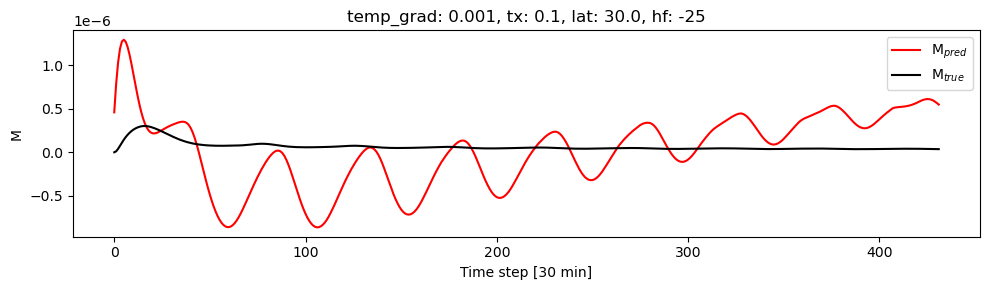

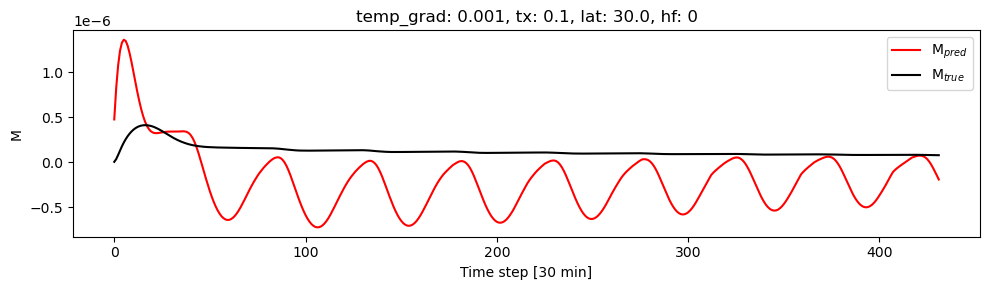

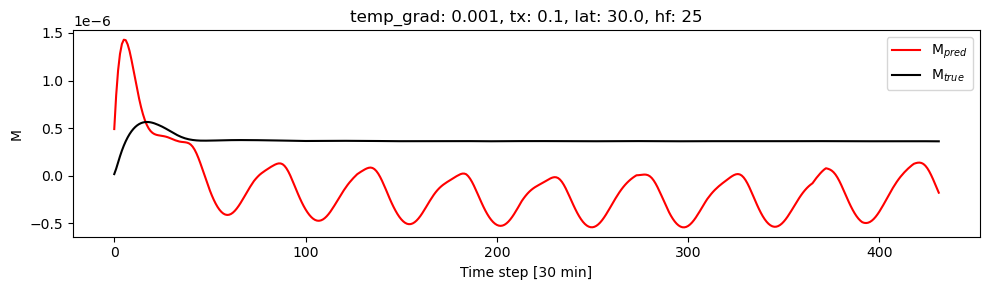

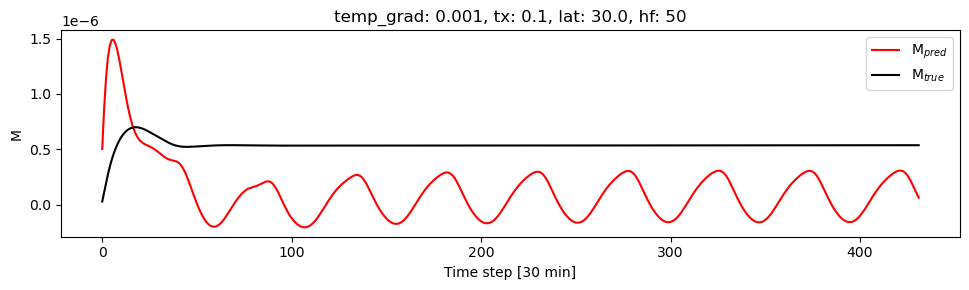

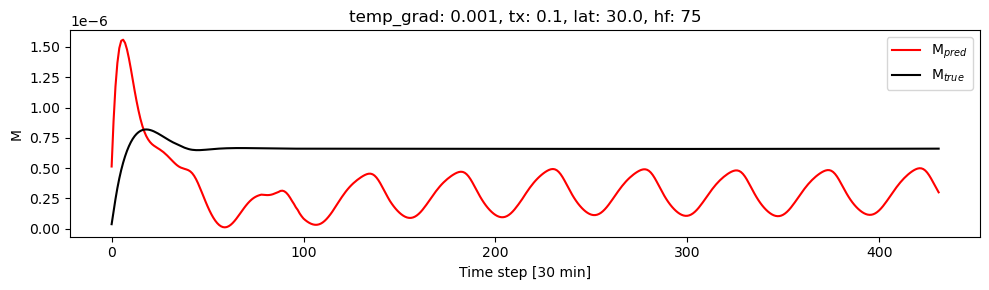

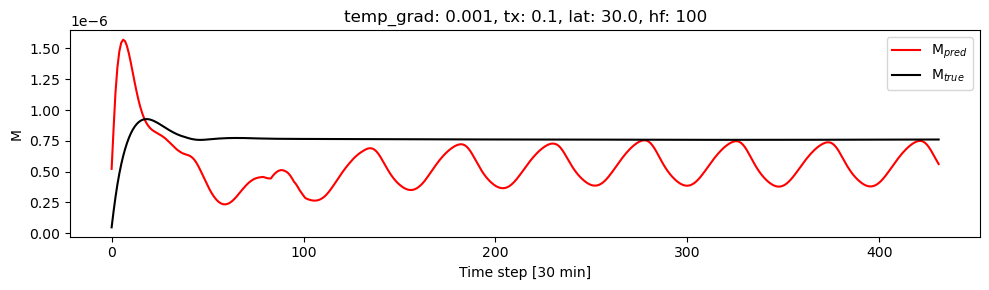

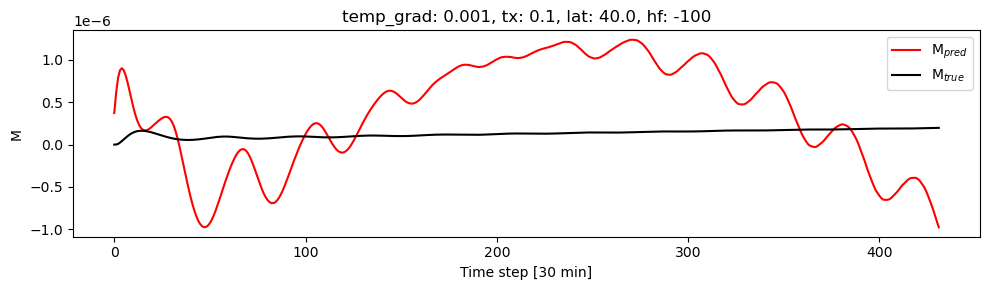

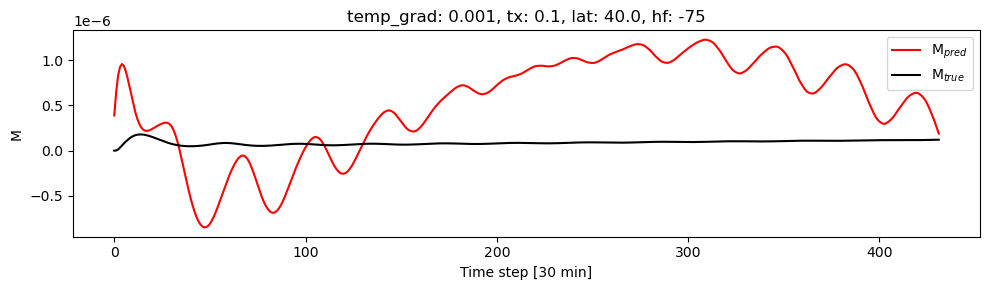

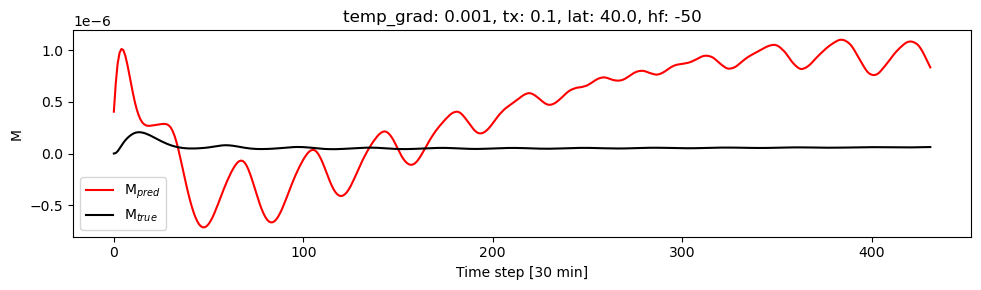

In [37]:
start, end = 0, 30
n_timesteps = 432

for i in range(start,end):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_full.detach().numpy()[i], label="M$_{pred}$", color="red")
    plt.plot(y[i], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()

/tmp/ipykernel_2147809/3574118397.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


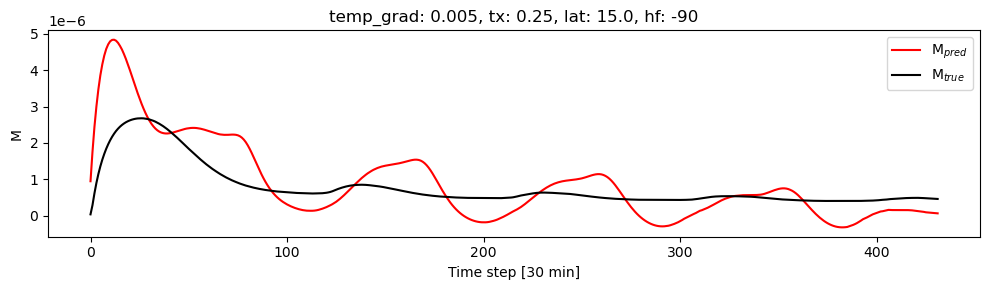

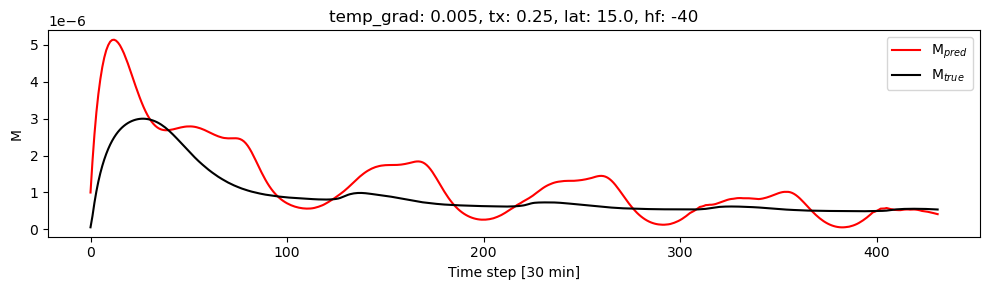

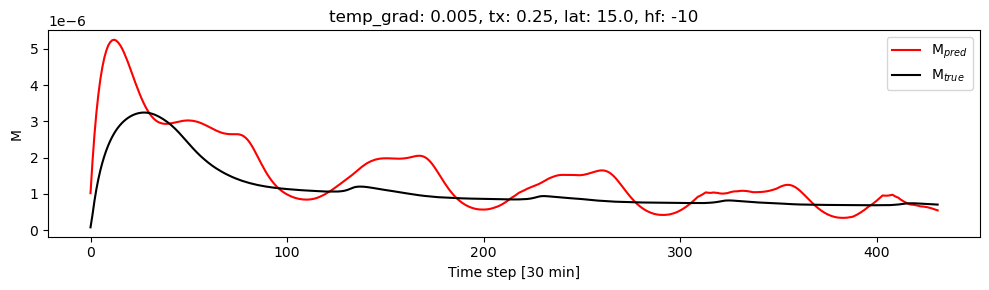

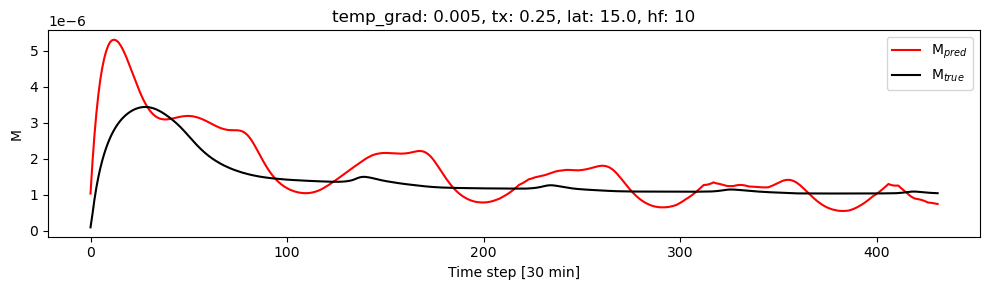

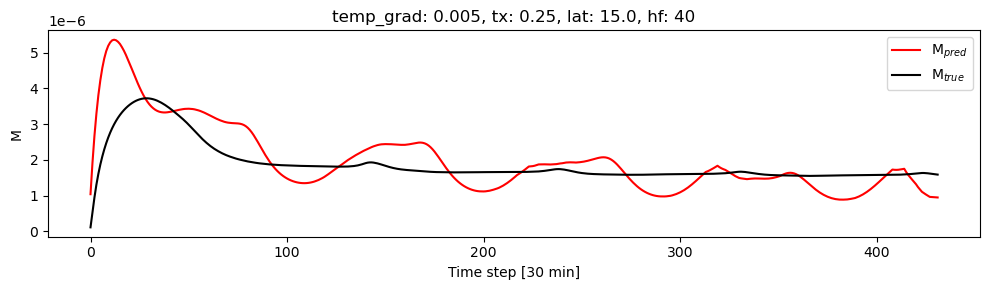

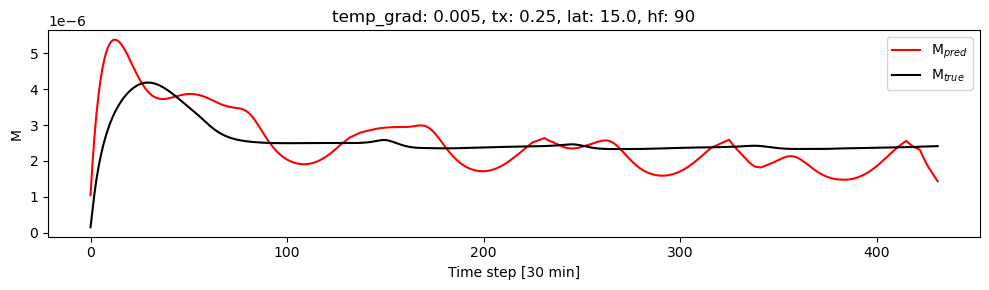

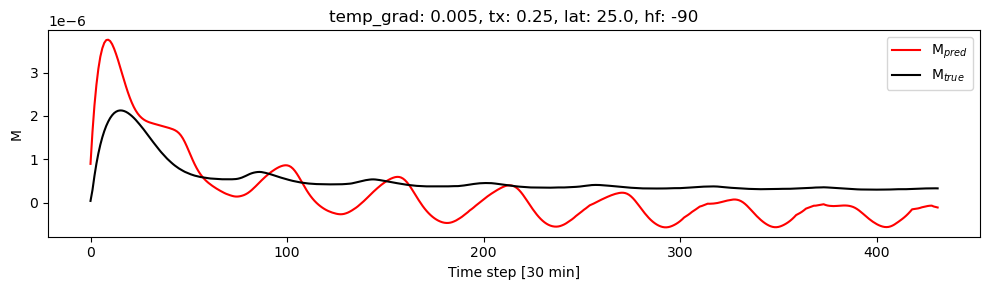

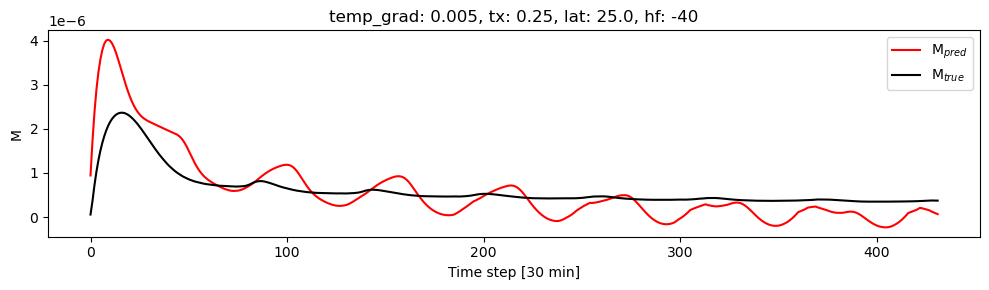

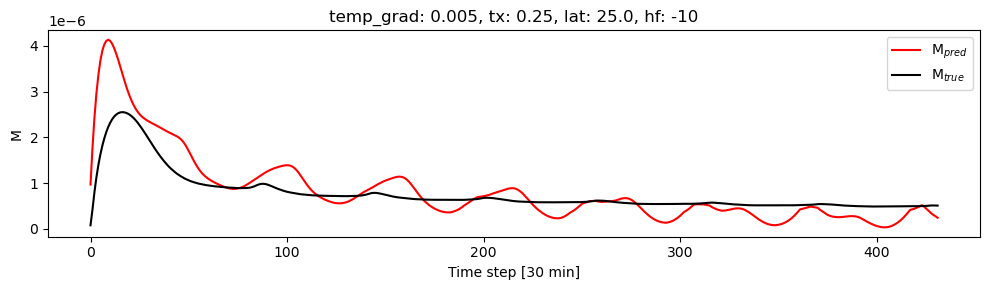

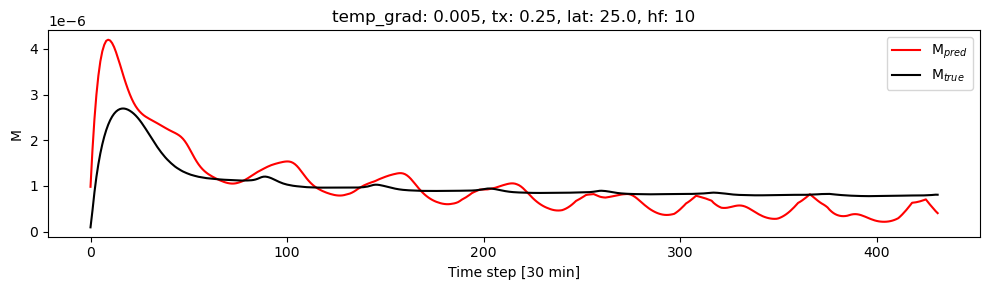

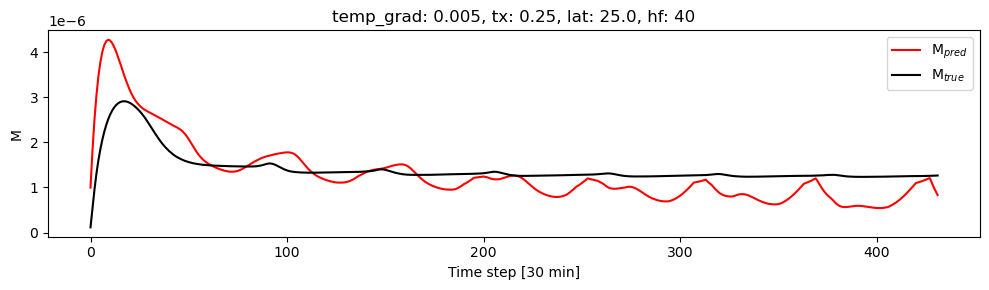

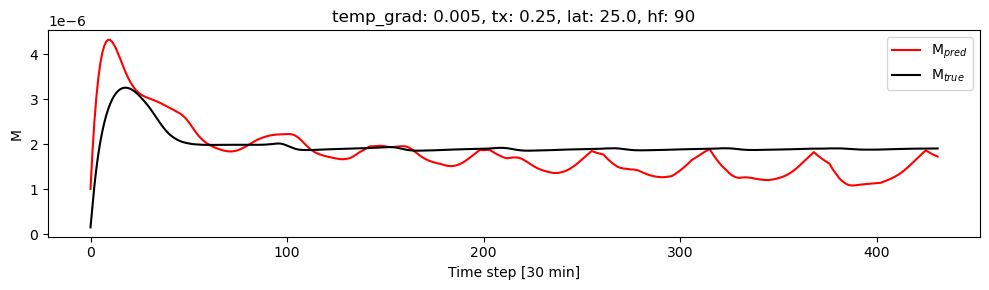

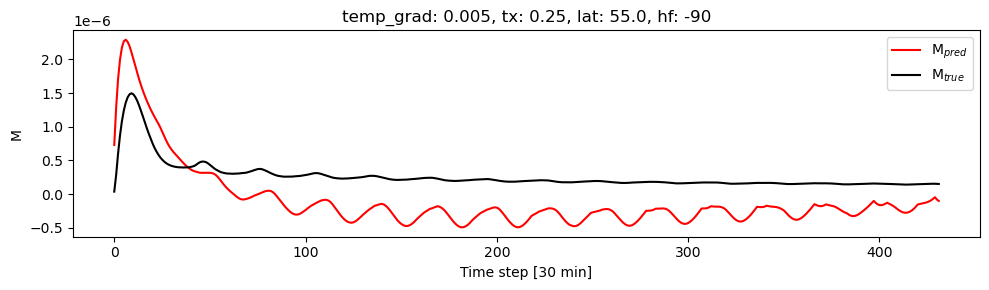

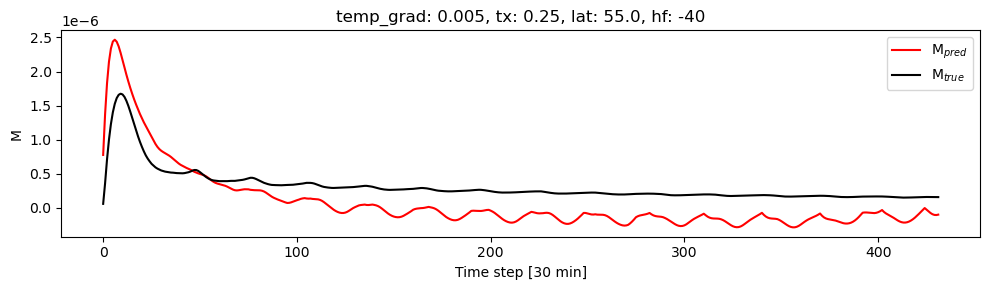

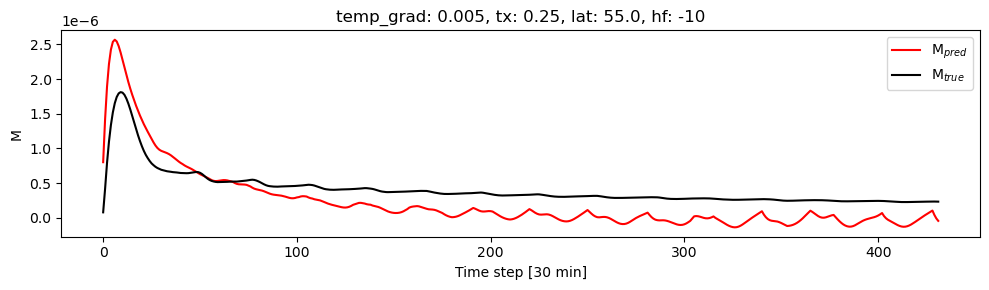

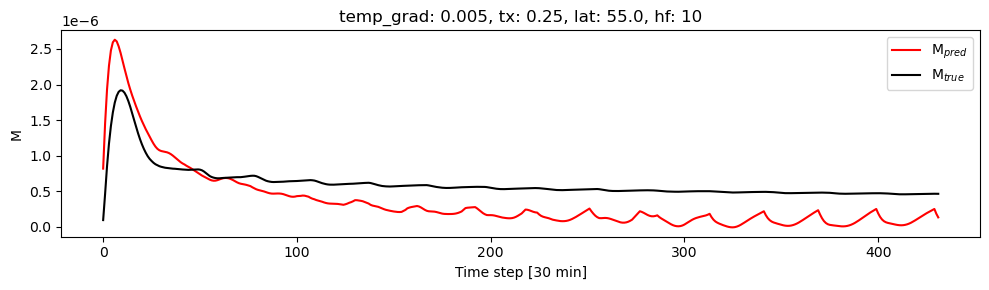

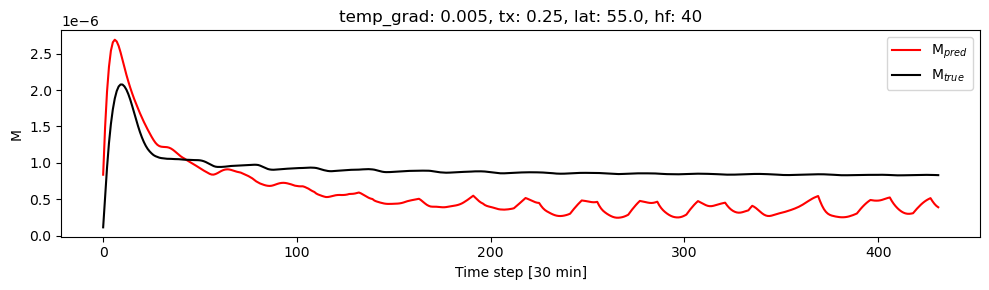

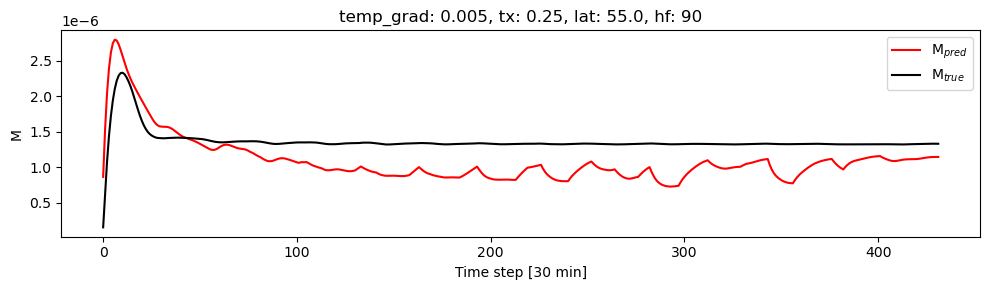

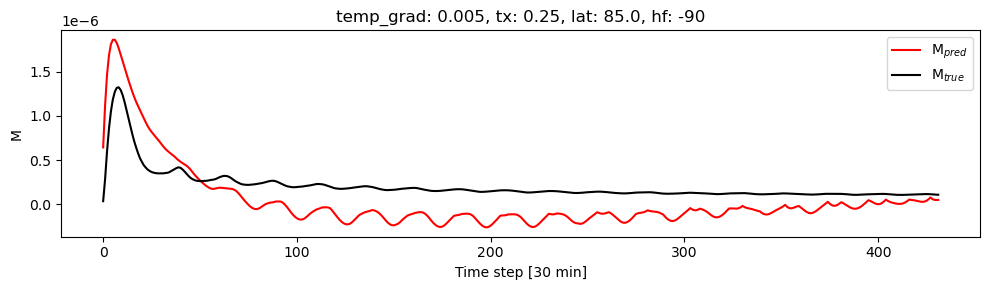

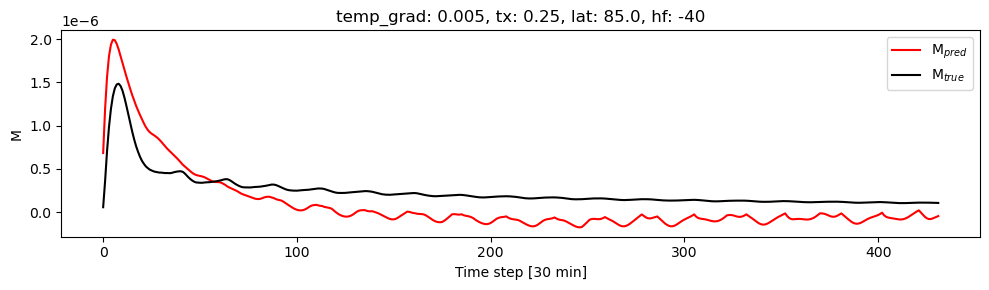

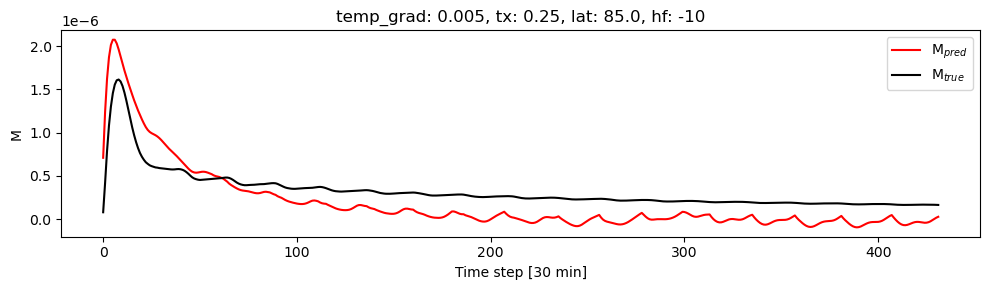

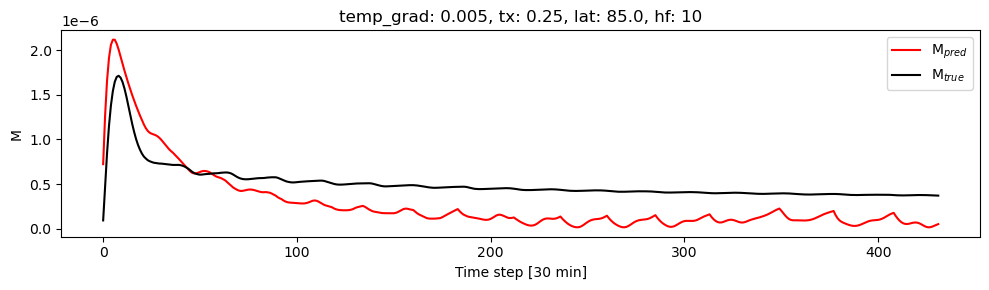

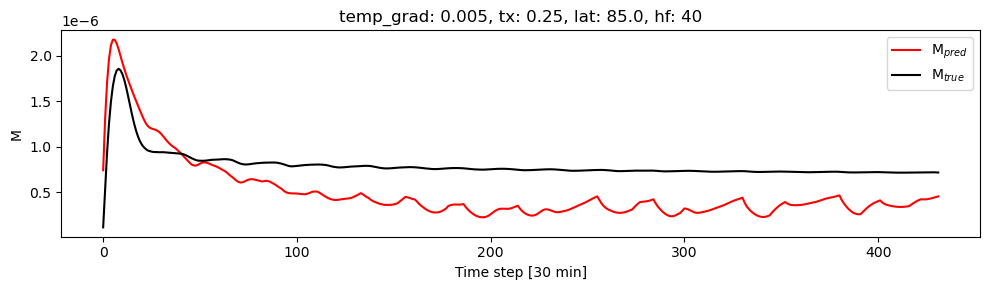

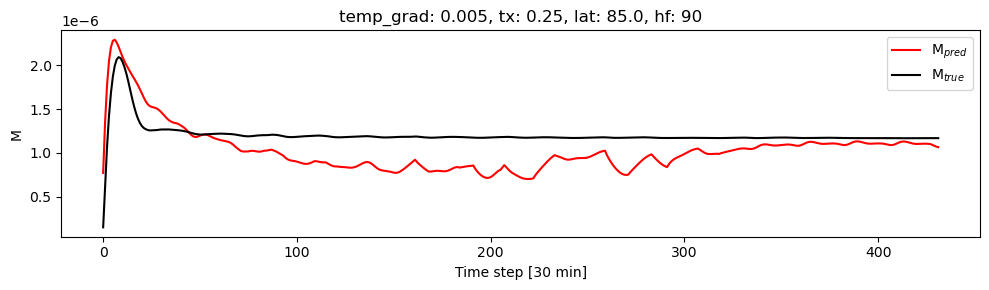

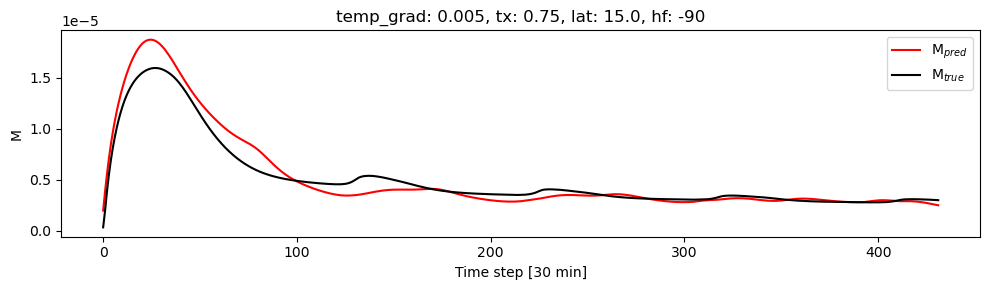

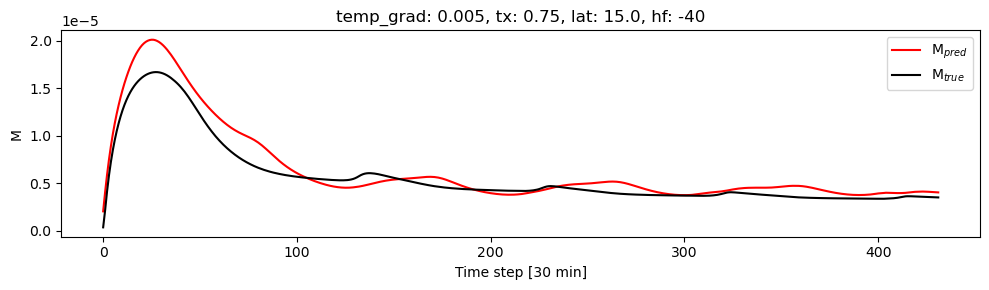

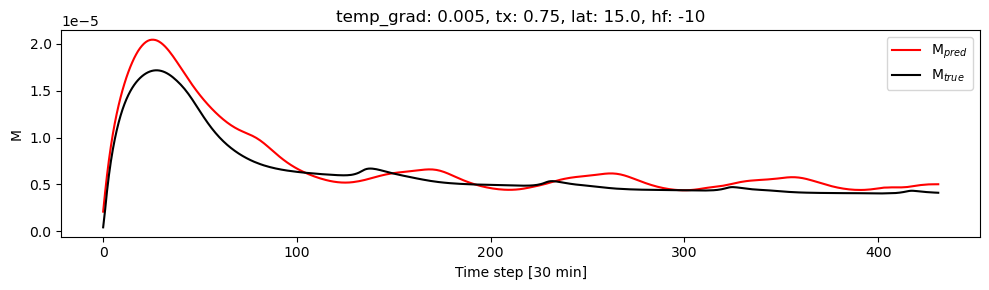

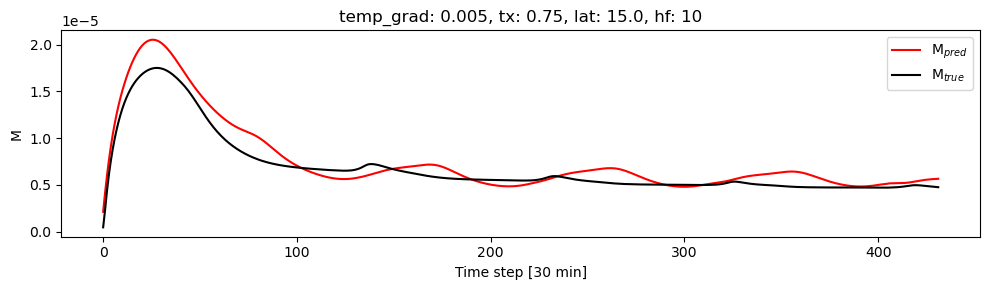

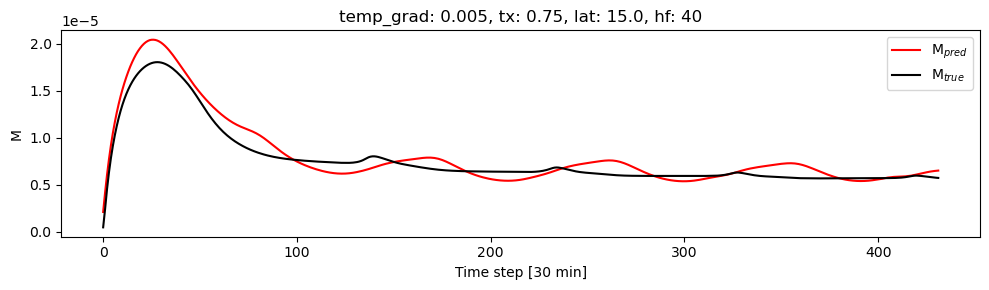

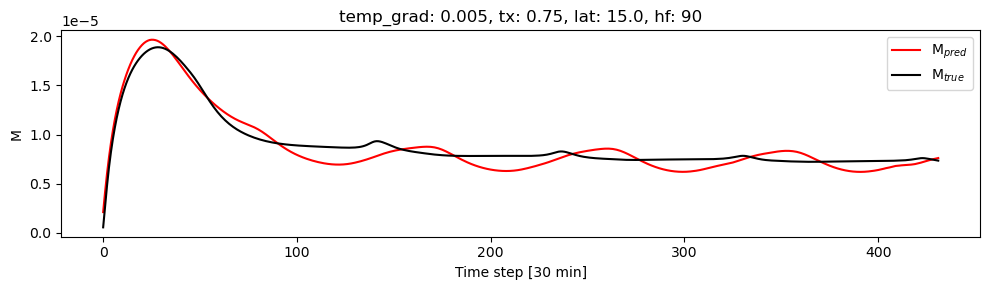

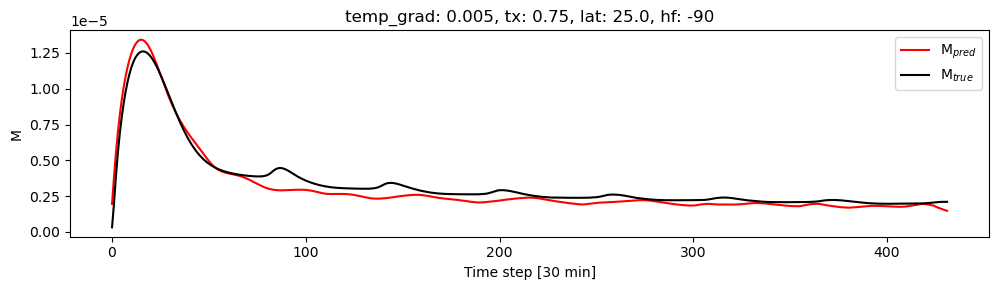

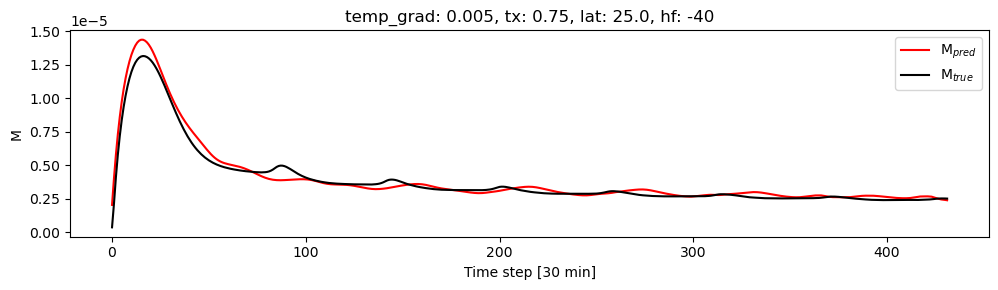

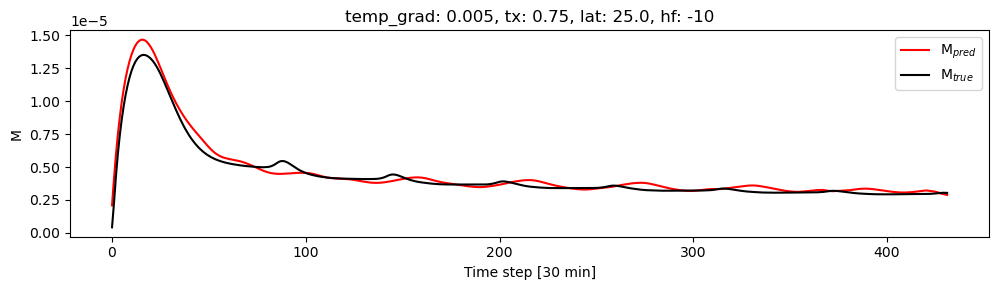

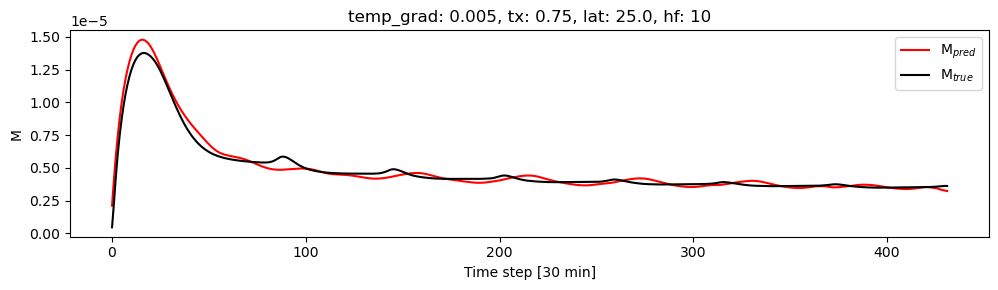

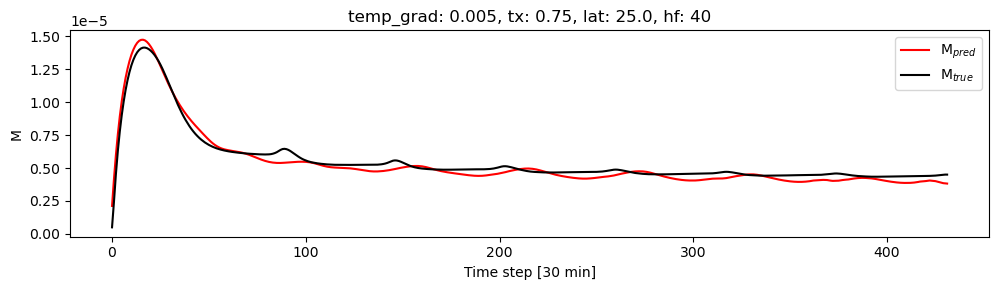

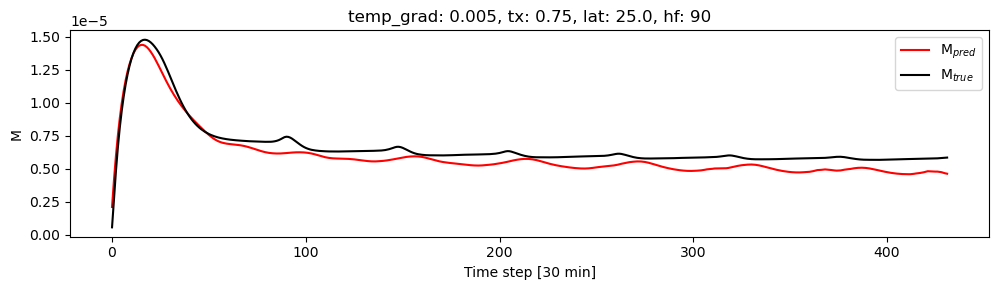

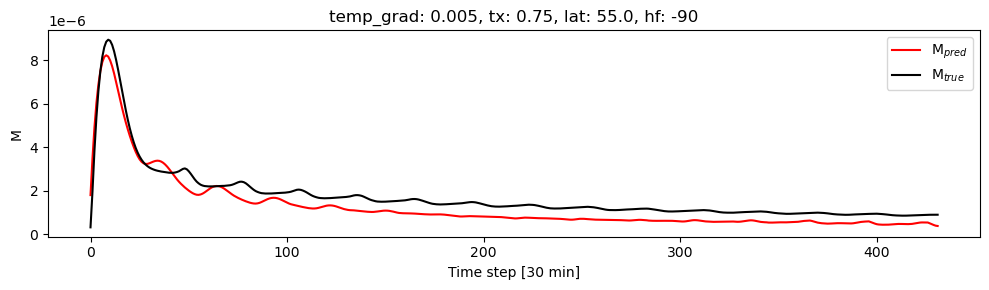

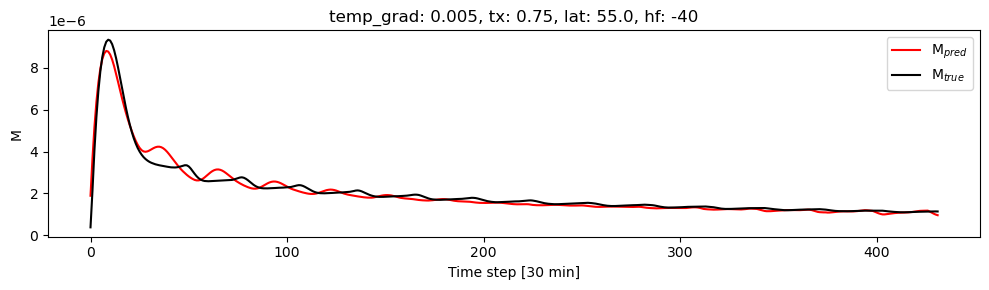

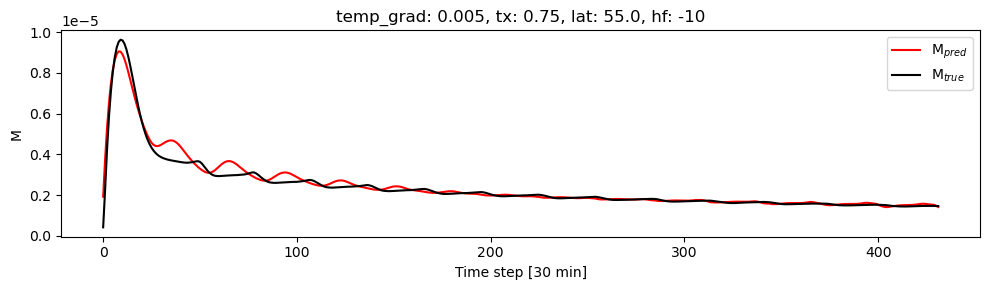

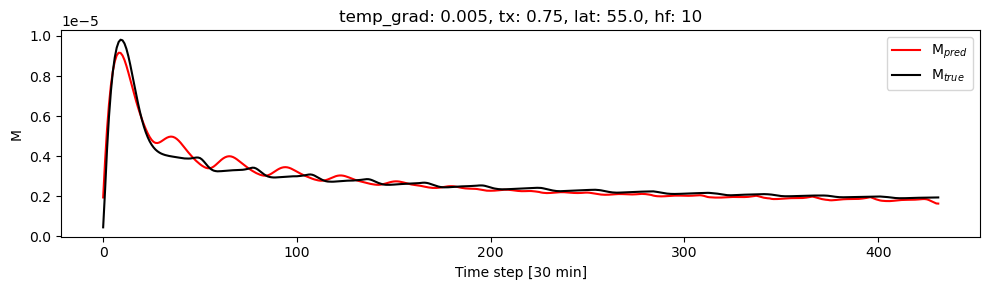

In [36]:
start, end = 0, 40
n_timesteps = 432

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_val_prediction_full.detach().numpy()[i], label="M$_{pred}$", color="red")
    plt.plot(y_val[i], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()

In [37]:
compute_rmse(y_pred=fcnn_val_prediction_full, y_true=y_val)

tensor(4.4777e-07, grad_fn=<SqrtBackward0>)

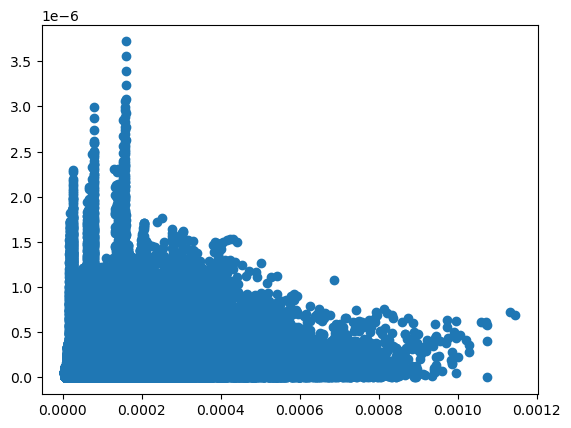

In [155]:
plt.scatter(X_val[:,10], (fcnn_val_prediction_full-y_val).abs().detach().numpy())